# Assignment 1

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV,KFold
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import  OneHotEncoder, StandardScaler
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error, r2_score,accuracy_score,recall_score,precision_score,f1_score,confusion_matrix

In [2]:
# Load the dataset
df = pd.read_csv(r"C:\FCDS\Machine Learning (ML)\project\car_price.csv")
print("dataset shape (rows , columns):", df.shape)
df.head()

dataset shape (rows , columns): (72435, 10)


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


In [3]:
# Dataset Information 
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         68814 non-null  object 
 1   year          68813 non-null  float64
 2   price         68814 non-null  float64
 3   transmission  68812 non-null  object 
 4   mileage       68813 non-null  float64
 5   fuelType      68813 non-null  object 
 6   tax           68814 non-null  float64
 7   mpg           68814 non-null  float64
 8   engineSize    68813 non-null  float64
 9   Make          68814 non-null  object 
dtypes: float64(6), object(4)
memory usage: 5.5+ MB


In [4]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,68813.000000,68814.000000,68813.000000,68814.000000,68814.000000,68813.000000
mean,2017.077660,16583.919261,23179.439539,116.930421,55.836352,1.635373
std,2.099474,9304.412707,21347.569657,64.081931,17.043643,0.561734
min,1996.000000,495.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,10167.250000,7199.000000,30.000000,47.900000,1.200000
50%,2017.000000,14495.000000,17521.000000,145.000000,55.400000,1.600000
75%,2019.000000,20359.750000,32478.000000,145.000000,62.800000,2.000000
max,2020.000000,145000.000000,323000.000000,580.000000,470.800000,6.600000


In [5]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
model           3621
year            3622
price           3621
transmission    3623
mileage         3622
fuelType        3622
tax             3621
mpg             3621
engineSize      3622
Make            3621
dtype: int64


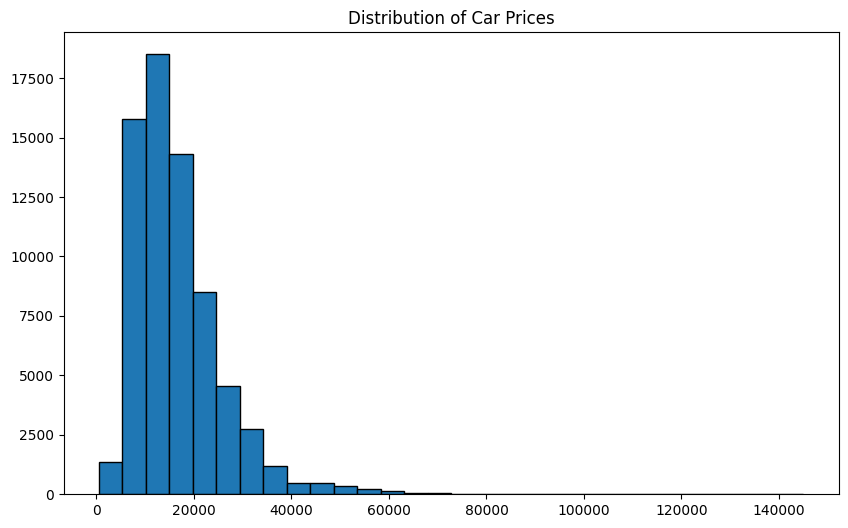

2.1808735153613923


In [6]:
# Distribution of Prices
plt.figure(figsize=(10, 6))
plt.hist(df['price'], bins=30, edgecolor = 'black')
plt.title('Distribution of Car Prices')
plt.show()
print(df['price'].skew()) # right skewed

In [7]:
# we drop model because it has too many unique values and it is not useful for our model
print("Unique values in 'model' column:", df['model'].nunique())
df.drop('model', axis=1, inplace=True)
df.shape

Unique values in 'model' column: 145


(72435, 9)

In [8]:
df['car_age'] = 2026 - df['year']
df['km_per_year'] = df['mileage'] / df['car_age']
df.drop(['year', 'mileage'], axis=1, inplace=True)
df.head()

,price,transmission,fuelType,tax,mpg,engineSize,Make,car_age,km_per_year
0,12500.0,Manual,Petrol,150.0,55.4,1.4,audi,9.0,1748.333333
1,16500.0,Automatic,Diesel,20.0,64.2,2.0,audi,10.0,3620.300000
2,11000.0,Manual,Petrol,30.0,55.4,1.4,audi,10.0,2994.600000
3,16800.0,Automatic,Diesel,145.0,67.3,2.0,audi,9.0,2883.555556
4,17300.0,Manual,Petrol,145.0,49.6,1.0,audi,7.0,285.428571


In [9]:
# percentage of missing values in each column 
# to decide which columns to drop or impute or flag

df.isnull().mean()*100

price           4.998965
transmission    5.001726
fuelType        5.000345
tax             4.998965
mpg             4.998965
engineSize      5.000345
Make            4.998965
car_age         5.000345
km_per_year     9.695589
dtype: float64

In [10]:
# drop rows with missing values in price
df.dropna(subset=['price'], inplace=True)
df.shape

(68814, 9)

In [11]:
# splitting the dataset 
x = df.drop('price', axis=1)
y = df['price']
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=42)
print("Training set shape:", x_train.shape, y_train.shape)
print("Testing set shape:", x_test.shape, y_test.shape)

Training set shape: (55051, 8) (55051,)
Testing set shape: (13763, 8) (13763,)


In [12]:
# Numerical Columns:Impute missing values based on train median 
train_numerical_cols = x_train.select_dtypes(include=np.number).columns
imputer = SimpleImputer(strategy='median')
x_train[train_numerical_cols] = imputer.fit_transform(x_train[train_numerical_cols])
x_train

,transmission,fuelType,tax,mpg,engineSize,Make,car_age,km_per_year
19785,Automatic,Diesel,145.0,47.9,3.0,BMW,7.0,527.571429
43740,NaN,Petrol,150.0,32.8,2.0,vw,6.0,500.000000
61606,Automatic,Petrol,150.0,31.7,2.0,skoda,7.0,2072.428571
46219,Manual,Petrol,145.0,47.9,1.0,vw,6.0,500.000000
63550,Semi-Auto,Diesel,145.0,64.2,2.0,skoda,7.0,273.000000
...,...,...,...,...,...,...,...,...
39177,Automatic,Diesel,150.0,52.3,2.0,Ford,10.0,2204.000000
6551,Semi-Auto,Petrol,145.0,43.5,1.5,audi,9.0,1993.518182
57779,Automatic,Hybrid,0.0,70.6,1.8,toyota,10.0,4241.500000
885,Automatic,Diesel,145.0,47.9,1.6,audi,7.0,1135.000000


In [13]:
# Numerical Columns:Impute missing values based on test median
test_numerical_cols = x_test.select_dtypes(include=np.number).columns
x_test[test_numerical_cols] = imputer.transform(x_test[test_numerical_cols])
x_test

,transmission,fuelType,tax,mpg,engineSize,Make,car_age,km_per_year
10010,Manual,Diesel,30.0,55.4,2.0,audi,10.0,10715.000000
44440,Automatic,Petrol,145.0,43.5,1.5,vw,7.0,957.142857
34162,Manual,Diesel,145.0,74.3,1.5,Ford,8.0,2710.000000
65482,Semi-Auto,Petrol,125.0,51.4,1.2,skoda,10.0,2860.000000
16162,Semi-Auto,Diesel,145.0,54.3,2.0,BMW,7.0,729.142857
...,...,...,...,...,...,...,...,...
36850,NaN,Petrol,20.0,55.4,1.0,Ford,11.0,1863.454545
18817,Automatic,Diesel,145.0,65.7,2.0,BMW,9.0,9914.666667
26683,Manual,Diesel,145.0,60.1,2.0,Ford,8.0,1963.625000
2197,Semi-Auto,Petrol,145.0,60.1,1.4,audi,12.0,2076.166667


In [14]:
# Categorical Columns: Impute issing values based on train mode 
train_categorical_cols = x_train.select_dtypes(include='object').columns

cat_imputer = SimpleImputer(strategy='most_frequent')

x_train[train_categorical_cols] = cat_imputer.fit_transform(x_train[train_categorical_cols])
x_train

,transmission,fuelType,tax,mpg,engineSize,Make,car_age,km_per_year
19785,Automatic,Diesel,145.0,47.9,3.0,BMW,7.0,527.571429
43740,Manual,Petrol,150.0,32.8,2.0,vw,6.0,500.000000
61606,Automatic,Petrol,150.0,31.7,2.0,skoda,7.0,2072.428571
46219,Manual,Petrol,145.0,47.9,1.0,vw,6.0,500.000000
63550,Semi-Auto,Diesel,145.0,64.2,2.0,skoda,7.0,273.000000
...,...,...,...,...,...,...,...,...
39177,Automatic,Diesel,150.0,52.3,2.0,Ford,10.0,2204.000000
6551,Semi-Auto,Petrol,145.0,43.5,1.5,audi,9.0,1993.518182
57779,Automatic,Hybrid,0.0,70.6,1.8,toyota,10.0,4241.500000
885,Automatic,Diesel,145.0,47.9,1.6,audi,7.0,1135.000000


In [15]:
# Categorical Columns: Impute missing values in test set
test_categorical_cols = x_test.select_dtypes(include='object').columns
x_test[test_categorical_cols] = cat_imputer.transform(x_test[test_categorical_cols])
x_test

,transmission,fuelType,tax,mpg,engineSize,Make,car_age,km_per_year
10010,Manual,Diesel,30.0,55.4,2.0,audi,10.0,10715.000000
44440,Automatic,Petrol,145.0,43.5,1.5,vw,7.0,957.142857
34162,Manual,Diesel,145.0,74.3,1.5,Ford,8.0,2710.000000
65482,Semi-Auto,Petrol,125.0,51.4,1.2,skoda,10.0,2860.000000
16162,Semi-Auto,Diesel,145.0,54.3,2.0,BMW,7.0,729.142857
...,...,...,...,...,...,...,...,...
36850,Manual,Petrol,20.0,55.4,1.0,Ford,11.0,1863.454545
18817,Automatic,Diesel,145.0,65.7,2.0,BMW,9.0,9914.666667
26683,Manual,Diesel,145.0,60.1,2.0,Ford,8.0,1963.625000
2197,Semi-Auto,Petrol,145.0,60.1,1.4,audi,12.0,2076.166667


In [16]:
# Confirm
print('Remaining missing values in train set:', x_train.isnull().sum().sum())
print('Remaining missing values in test set:', x_test.isnull().sum().sum())


Remaining missing values in train set: 0
Remaining missing values in test set: 0


In [17]:
# check for duplicates
x_train.duplicated().sum()

3133

In [18]:
# Drop duplicates
x_train.drop_duplicates()

,transmission,fuelType,tax,mpg,engineSize,Make,car_age,km_per_year
19785,Automatic,Diesel,145.0,47.9,3.0,BMW,7.0,527.571429
43740,Manual,Petrol,150.0,32.8,2.0,vw,6.0,500.000000
61606,Automatic,Petrol,150.0,31.7,2.0,skoda,7.0,2072.428571
46219,Manual,Petrol,145.0,47.9,1.0,vw,6.0,500.000000
63550,Semi-Auto,Diesel,145.0,64.2,2.0,skoda,7.0,273.000000
...,...,...,...,...,...,...,...,...
39177,Automatic,Diesel,150.0,52.3,2.0,Ford,10.0,2204.000000
6551,Semi-Auto,Petrol,145.0,43.5,1.5,audi,9.0,1993.518182
57779,Automatic,Hybrid,0.0,70.6,1.8,toyota,10.0,4241.500000
885,Automatic,Diesel,145.0,47.9,1.6,audi,7.0,1135.000000


In [19]:
# Using IQR method for numerical columns in x_train to detect and replace outkiers with median
IQR_cols = ['car_age', 'km_per_year','tax','mpg','engineSize'] 
for col in IQR_cols:
    Q1 = x_train[col].quantile(0.25)
    Q3 = x_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    IQR_outliers = x_train[(x_train[col] < lower_bound) | (x_train[col] > upper_bound)]
    print(f"Outliers in {col}:",len(IQR_outliers[[col]]))
    median = x_train[col].median()
    x_train.loc[(x_train[col] < lower_bound) | (x_train[col] > upper_bound), col] = median
    IQR_outliers = x_train[(x_train[col] < lower_bound) | (x_train[col] > upper_bound)]
    print(f"Outliers after replacement in {col}:",len(IQR_outliers[[col]]))
    

Outliers in car_age: 897
Outliers after replacement in car_age: 0
Outliers in km_per_year: 1723
Outliers after replacement in km_per_year: 0
Outliers in tax: 15856
Outliers after replacement in tax: 0
Outliers in mpg: 799
Outliers after replacement in mpg: 0
Outliers in engineSize: 246
Outliers after replacement in engineSize: 0


In [20]:
y_train = y_train.clip(
    y_train.quantile(0.01),
    y_train.quantile(0.99)
)

In [21]:

# One-Hot Encoding for all categorical Features

enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
train_enc = enc.fit_transform(x_train[['transmission','fuelType','Make']])
test_enc = enc.transform(x_test[['transmission','fuelType','Make']])

# Reconstruct DataFrame
train_enc_df = pd.DataFrame(train_enc, columns=enc.get_feature_names_out(['transmission','fuelType','Make']), index=x_train.index)
test_enc_df = pd.DataFrame(test_enc, columns=enc.get_feature_names_out(['transmission','fuelType','Make']), index=x_test.index)
x_train = pd.concat([x_train.drop(['transmission','fuelType','Make'], axis=1), train_enc_df], axis=1)
x_test = pd.concat([x_test.drop(['transmission','fuelType','Make'], axis=1), test_enc_df], axis=1)
x_train.head()

,tax,mpg,engineSize,car_age,km_per_year,transmission_Automatic,transmission_Manual,transmission_Other,transmission_Semi-Auto,fuelType_Diesel,...,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,Make_BMW,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,Make_toyota,Make_vw
19785,145.0,47.9,3.0,7.0,527.571429,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
43740,150.0,32.8,2.0,6.0,500.000000,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
61606,150.0,31.7,2.0,7.0,2072.428571,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
46219,145.0,47.9,1.0,6.0,500.000000,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
63550,145.0,64.2,2.0,7.0,273.000000,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [22]:
ss = StandardScaler()
train_scaled = ss.fit_transform(x_train)
test_scaled = ss.transform(x_test)

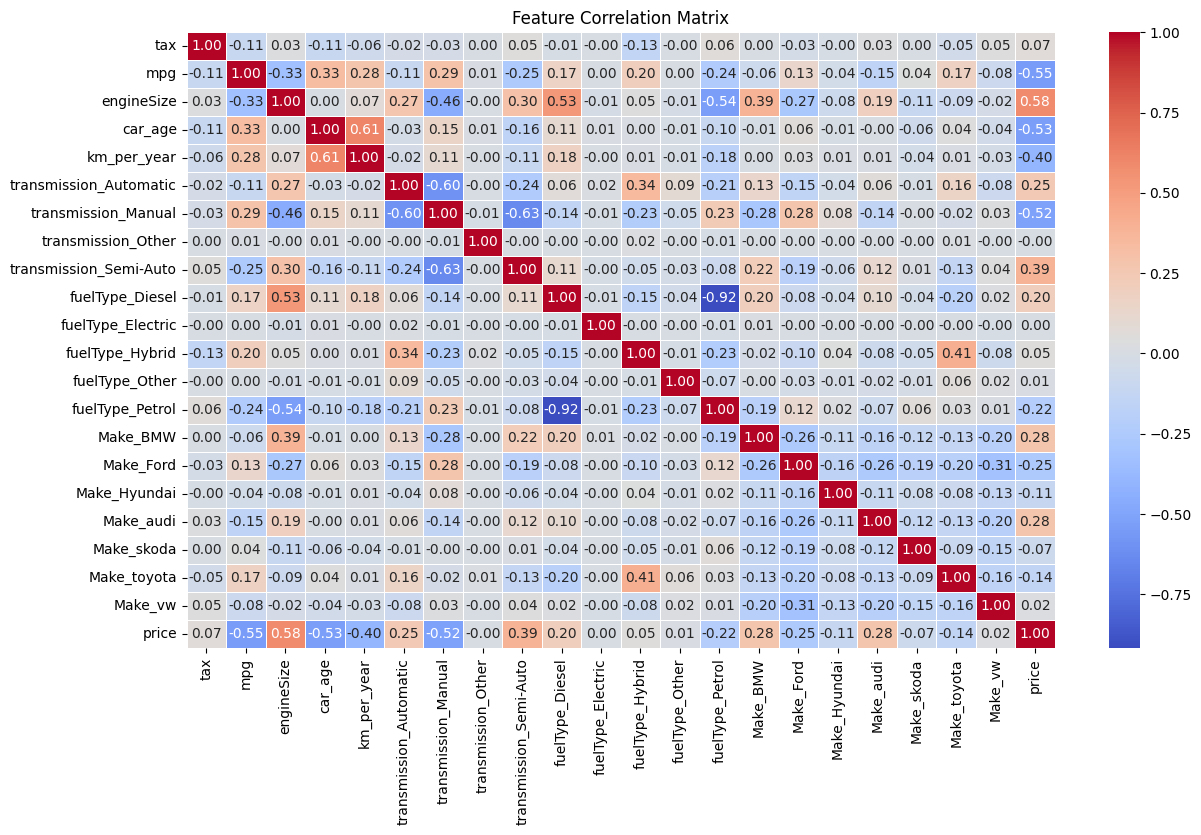

The feature with the strongest correlation to Price is: engineSize


In [23]:
plt.figure(figsize=(14, 8))
correlation_matrix = pd.concat([x_train, y_train], axis=1).corr()

# Visualize the heatmap
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

# Find the feature with the highest correlation to price
top_feature = correlation_matrix['price'].drop('price').abs().idxmax()
print(f"The feature with the strongest correlation to Price is: {top_feature}")

In [24]:
# Regression variables
x_train_reg = x_train
x_test_reg = x_test
y_train_log = np.log(y_train)
y_test_reg = y_test

# Regression Model
reg_model = LinearRegression()
reg_model.fit(x_train_reg, y_train_log)
y_pred_log = reg_model.predict(x_test_reg)
y_pred = np.expm1(y_pred_log)

# Evaluate the model
print(f"R2 Score: {r2_score(y_test_reg, y_pred):.4f}")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test_reg, y_pred)):.2f}")


R2 Score: 0.7971
Root Mean Squared Error: 4155.27


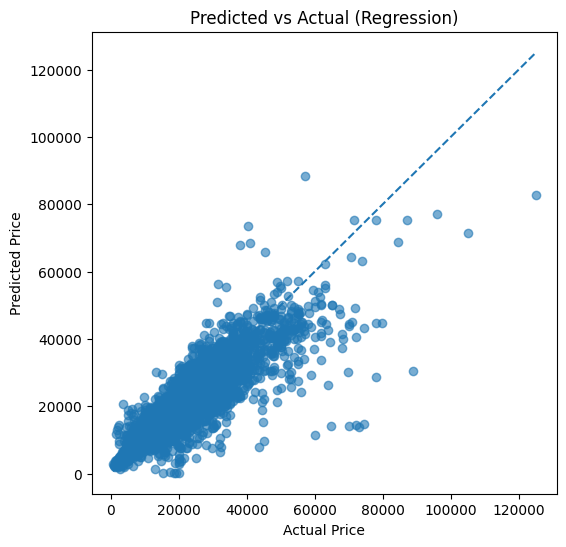

In [25]:
plt.figure(figsize=(6,6))

# scatter plot
plt.scatter(y_test_reg, y_pred, alpha=0.6)

plt.plot(
    [y_test_reg.min(), y_test_reg.max()],
    [y_test_reg.min(), y_test_reg.max()],
    linestyle='--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual (Regression)")
plt.show()

In [26]:
# thresholds
low = y_train.quantile(0.33)
high = y_train.quantile(0.66)

# Classification variables
def classify(price):
    if price <= low:
        return 'Cheap'
    elif price <= high:
        return 'Moderate'
    else:
        return 'Expensive'
    
y_train_clf = y_train.apply(classify)
y_test_clf = y_test.apply(classify)

# Grid Search for KNN
param_grid = {
    'n_neighbors': range(1, 31),
    'metric': ['euclidean', 'manhattan']

}

knn = KNeighborsClassifier()
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=kfold,
    scoring='accuracy',
    n_jobs=-1,
)

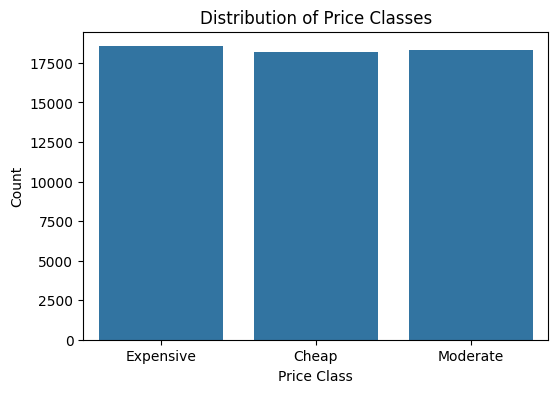

In [27]:
# Check if data is balanced (additional plot)
plt.figure(figsize=(6,4))
sns.countplot(x=y_train_clf)

plt.title("Distribution of Price Classes")
plt.xlabel("Price Class")
plt.ylabel("Count")

plt.show()

In [28]:
grid_search.fit(x_train, y_train_clf)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy: {:.4f}".format(grid_search.best_score_))

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 4}
Best CV Accuracy: 0.6594


In [29]:
y_pred = grid_search.best_estimator_.predict(x_test)

# Evaluate the model
accuracy = accuracy_score(y_test_clf, y_pred)
precision = precision_score(y_test_clf, y_pred, average='weighted')
recall = recall_score(y_test_clf, y_pred, average='weighted')
f1 = f1_score(y_test_clf, y_pred, average='weighted')

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")


Accuracy:  0.6214
Precision: 0.6214
Recall:    0.6214
F1-Score:  0.6204


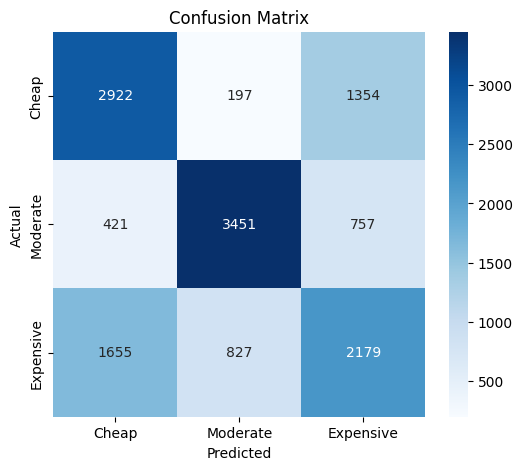

In [30]:
cm = confusion_matrix(y_test_clf, y_pred)

# plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',cmap='Blues',
            xticklabels=['Cheap','Moderate','Expensive'],
            yticklabels=['Cheap','Moderate','Expensive'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

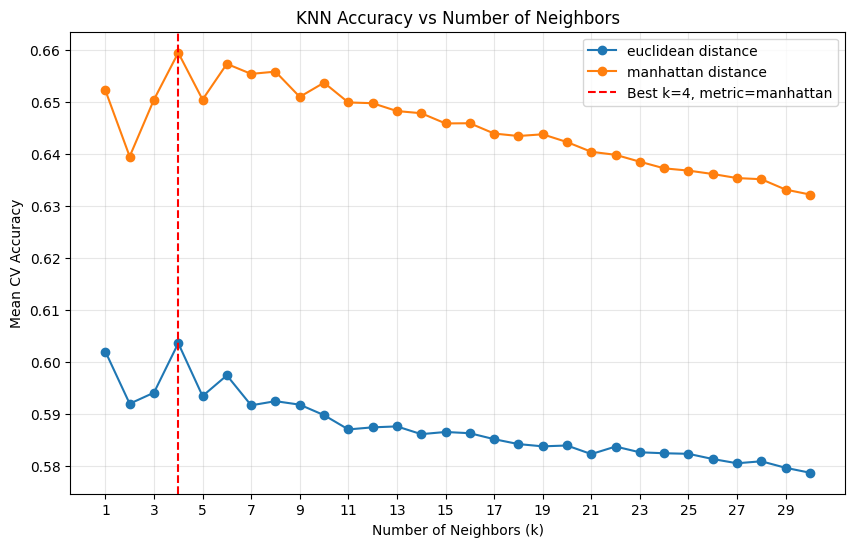

In [31]:
# Plotting KNN Accuracy vs Number of Neighbors (additional plot)
results = pd.DataFrame(grid_search.cv_results_)

plt.figure(figsize=(10,6))

# Plot for each metric type
for metric in ['euclidean', 'manhattan']:
    subset = results[results['param_metric'] == metric]
    plt.plot(subset['param_n_neighbors'],
             subset['mean_test_score'],
             label=f'{metric} distance',
             marker='o')

best_k = grid_search.best_params_['n_neighbors']
best_metric = grid_search.best_params_['metric']
plt.axvline(best_k, color='red', linestyle='--',
            label=f'Best k={best_k}, metric={best_metric}')

plt.title('KNN Accuracy vs Number of Neighbors')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean CV Accuracy')
plt.xticks(np.arange(1, 31, 2))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Machine Learning Assignment 2
## FIFA Players Performance Analysis



In [32]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, PolynomialFeatures, Binarizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_recall_fscore_support, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, make_scorer
)

RANDOM_STATE = 42
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 120)


def rmse_score(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def make_ohe():
    # Works with both newer and older sklearn versions.
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=True)


In [33]:
# Load dataset
df = pd.read_csv(r"C:\FCDS\Machine Learning (ML)\project\Fifa.csv")
print('Dataset shape:', df.shape)
df.head()


Dataset shape: (19667, 9)


,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640


In [34]:
print(df.info())
df.describe(include='all').T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  object 
 1   Country            19667 non-null  object 
 2   Position           19667 non-null  object 
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  object 
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 1.4+ MB
None


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Name,19667,19551,Diego González,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,19667,164,England,1549,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Position,19667,17,CB,2981,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,19667.0,NaN,NaN,NaN,22.990034,4.69241,15.0,19.0,22.0,26.0,44.0
Overall_Rating,19667.0,NaN,NaN,NaN,63.225403,7.812716,36.0,58.0,63.0,68.0,91.0
Future Potential,19667.0,NaN,NaN,NaN,70.658718,6.489551,46.0,66.0,70.0,75.0,95.0
Team,19667,1009,River Plate,107,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Value Per M$,19667.0,NaN,NaN,NaN,2.514639,7.256974,0.0,0.325,0.675,1.6,190.5
Total_Stats Score,19667.0,NaN,NaN,NaN,1534.513907,283.248088,416.0,1388.0,1549.0,1720.0,2324.0


# Task 1: Exploratory Data Analysis (EDA)




In [35]:
missing_values = df.isna().sum()
missing_table = pd.DataFrame({
    'missing_count': missing_values,
    'missing_percentage': (missing_values / len(df) * 100).round(2)
})
missing_table


,missing_count,missing_percentage
Name,0,0.0
Country,0,0.0
Position,0,0.0
Age,0,0.0
Overall_Rating,0,0.0
Future Potential,0,0.0
Team,0,0.0
Value Per M$,0,0.0
Total_Stats Score,0,0.0


Skewness of Value Per M$: 7.9832


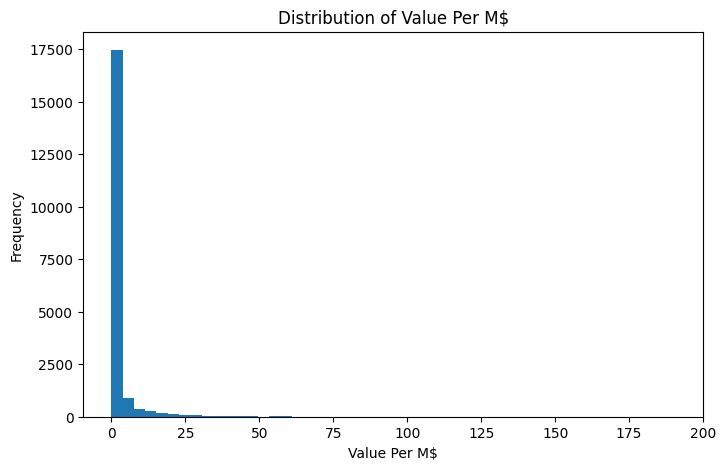

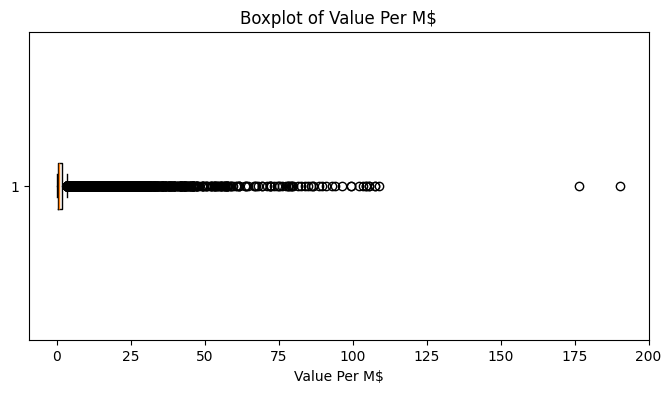

The distribution is strongly right-skewed.


In [36]:
value_col = 'Value Per M$'
value_skewness = df[value_col].skew()
print(f'Skewness of {value_col}: {value_skewness:.4f}')

plt.figure(figsize=(8, 5))
plt.hist(df[value_col].dropna(), bins=50)
plt.title('Distribution of Value Per M$')
plt.xlabel('Value Per M$')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8, 4))
plt.boxplot(df[value_col].dropna(), vert=False)
plt.title('Boxplot of Value Per M$')
plt.xlabel('Value Per M$')
plt.show()

if value_skewness > 1:
    print('The distribution is strongly right-skewed.')
elif value_skewness > 0.5:
    print('The distribution is moderately right-skewed.')
elif value_skewness < -0.5:
    print('The distribution is left-skewed.')
else:
    print('The distribution is approximately symmetric.')


Correlation with Value Per M$:


Value Per M$         1.000000
Overall_Rating       0.560648
Future Potential     0.500964
Total_Stats Score    0.385062
Age                  0.142276
Name: Value Per M$, dtype: float64

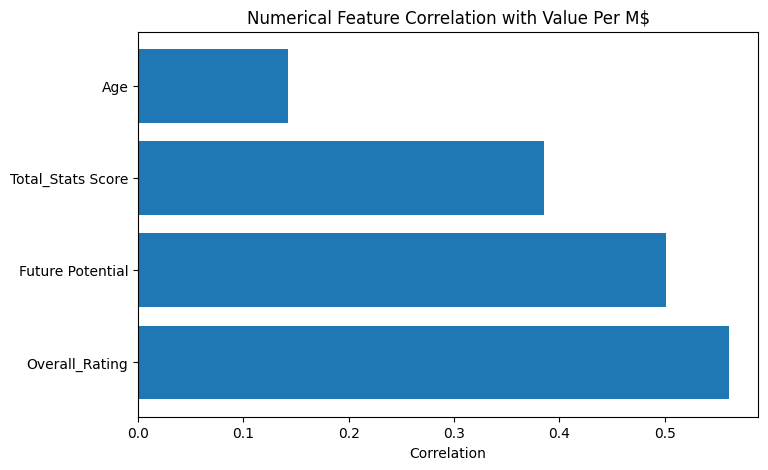

In [37]:
numerical_cols_all = df.select_dtypes(include=np.number).columns.tolist() 
correlations = df[numerical_cols_all].corr(numeric_only=True)[value_col].sort_values(ascending=False)
print('Correlation with Value Per M$:')
display(correlations)

plt.figure(figsize=(8, 5))
correlations=correlations.drop(value_col)
plt.barh(correlations.index, correlations.values)
plt.title('Numerical Feature Correlation with Value Per M$')
plt.xlabel('Correlation')
plt.show()


Position
SW     75.000000
RF     75.000000
CF     66.042857
LW     64.345979
CDM    64.234168
LM     64.172009
RWB    64.063973
LWB    64.043333
RM     63.907731
RW     63.718529
CAM    63.679709
CB     63.544448
LB     63.276794
ST     63.087505
RB     62.863636
CM     62.511767
GK     60.987288
Name: Overall_Rating, dtype: float64

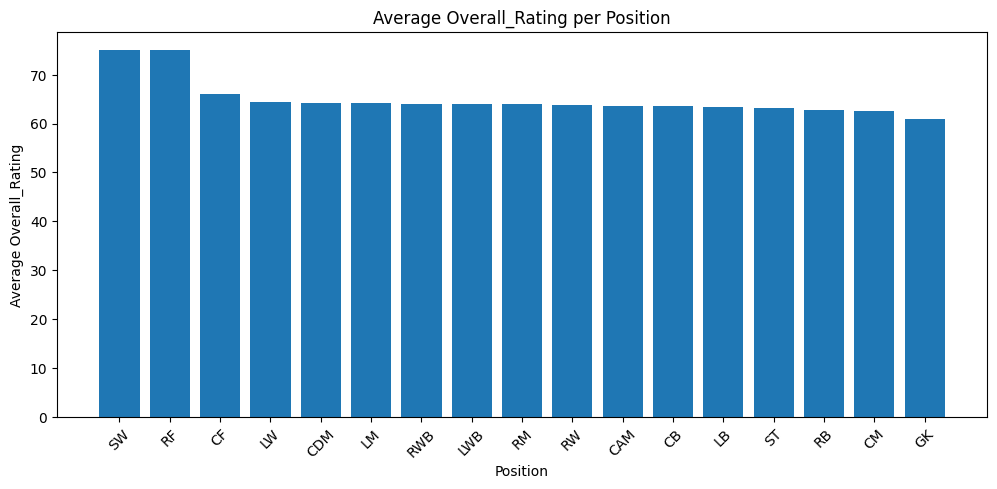

In [38]:
avg_rating_by_position = df.groupby('Position')['Overall_Rating'].mean().sort_values(ascending=False)
display(avg_rating_by_position)

plt.figure(figsize=(12, 5))
plt.bar(avg_rating_by_position.index, avg_rating_by_position.values)
plt.title('Average Overall_Rating per Position')
plt.xlabel('Position')
plt.ylabel('Average Overall_Rating')
plt.xticks(rotation=45)
plt.show()


# Task 2: Data Preprocessing

The dataset is split into train/test before preprocessing. Then encoding, scaling, and outlier handling are done inside pipelines. This prevents data leakage.

Outliers are handled by IQR winsorization: the lower and upper caps are learned from the training set only, then applied to train/test.


In [39]:
class IQR_CLIP(BaseEstimator, TransformerMixin):
    # Clips numerical features using IQR bounds learned from training data.
    def __init__(self, factor=1.5):
        self.factor = factor
        self.lower_bounds_ = None
        self.upper_bounds_ = None

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X).astype(float)
        q1 = X_df.quantile(0.25)
        q3 = X_df.quantile(0.75)
        iqr = q3 - q1
        self.lower_bounds_ = q1 - self.factor * iqr
        self.upper_bounds_ = q3 + self.factor * iqr
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X).astype(float)
        return X_df.clip(lower=self.lower_bounds_, upper=self.upper_bounds_, axis=1).values


In [40]:
# Detect outliers in original dataset for reporting
num_cols_for_outliers = ['Age', 'Overall_Rating', 'Future Potential', 'Value Per M$', 'Total_Stats Score']
outlier_summary = []
for col in num_cols_for_outliers:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append([col, lower, upper, count, round(count / len(df) * 100, 2)])

outlier_table = pd.DataFrame(outlier_summary, columns=['column', 'lower_bound', 'upper_bound', 'outlier_count', 'outlier_%'])
outlier_table


,column,lower_bound,upper_bound,outlier_count,outlier_%
0,Age,8.5000,36.5000,169,0.86
1,Overall_Rating,43.0000,83.0000,146,0.74
2,Future Potential,52.5000,88.5000,120,0.61
3,Value Per M$,-1.5875,3.5125,2390,12.15
4,Total_Stats Score,890.0000,2218.0000,788,4.01


In [ ]:
# Regression setup

target_regression = 'Value Per M$'
regression_features = ['Country', 'Position', 'Age', 'Overall_Rating', 'Future Potential', 'Team', 'Total_Stats Score']
regression_numeric_features = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']
regression_categorical_features = ['Country', 'Position', 'Team']

X_reg = df[regression_features].copy()
y_reg = df[target_regression].copy()

# Correct 80/20 split BEFORE preprocessing.
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=RANDOM_STATE
)

print('Regression train shape:', X_reg_train.shape)
print('Regression test shape:', X_reg_test.shape)


Regression train shape: (15733, 7)
Regression test shape: (3934, 7)


In [42]:
numeric_preprocess_reg = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('outlier_clipper', IQR_CLIP(factor=1.5)),
    ('scaler', StandardScaler())
])

categorical_preprocess = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', make_ohe())
])

preprocess_regression = ColumnTransformer(transformers=[
    ('num', numeric_preprocess_reg, regression_numeric_features),
    ('cat', categorical_preprocess, regression_categorical_features)
])


# Task 3: Create Classification Target

The performance tier target is based on `Overall_Rating`. Thresholds are chosen using quartiles, which is a data-driven method and helps keep the classes reasonably balanced.


Overall_Rating thresholds: Low <= 58.0, Mid <= 63.0, High <= 68.0, Elite > 68.0


Performance_Tier
Low      5568
Mid      5102
High     4297
Elite    4700
Name: count, dtype: int64

Performance_Tier
Low      28.31
Mid      25.94
High     21.85
Elite    23.90
Name: class_percentage, dtype: float64

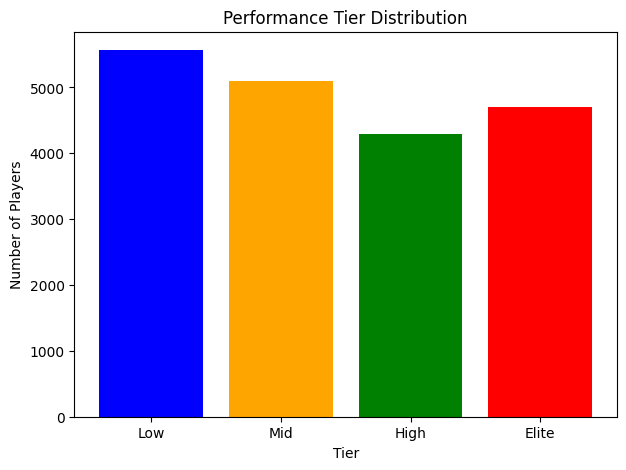

In [43]:
q25, q50, q75 = df['Overall_Rating'].quantile([0.25, 0.50, 0.75])
print(f'Overall_Rating thresholds: Low <= {q25}, Mid <= {q50}, High <= {q75}, Elite > {q75}')

def rating_to_tier(rating):
    if rating <= q25:
        return 'Low'
    elif rating <= q50:
        return 'Mid'
    elif rating <= q75:
        return 'High'
    else:
        return 'Elite'

df['Performance_Tier'] = df['Overall_Rating'].apply(rating_to_tier)
labels_order = ['Low', 'Mid', 'High', 'Elite']
class_counts = df['Performance_Tier'].value_counts().reindex(labels_order)
display(class_counts)

display((class_counts / len(df) * 100).round(2).rename('class_percentage'))

plt.figure(figsize=(7, 5))
plt.bar(class_counts.index, class_counts.values, color=['blue', 'orange', 'green', 'red'])
plt.title('Performance Tier Distribution')
plt.xlabel('Tier')
plt.ylabel('Number of Players')
plt.xticks(rotation=0)
plt.show()


In [ ]:
# Classification setup

classification_features = ['Country', 'Position', 'Age', 'Future Potential', 'Team', 'Value Per M$', 'Total_Stats Score']
classification_numeric_features = ['Age', 'Future Potential', 'Value Per M$', 'Total_Stats Score']
classification_categorical_features = ['Country', 'Position', 'Team']

X_clf = df[classification_features].copy()
y_clf = df['Performance_Tier'].copy()

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.20, random_state=RANDOM_STATE, stratify=y_clf
)

print('Train class distribution:')
display(y_clf_train.value_counts().reindex(labels_order))
print('Test class distribution:')
display(y_clf_test.value_counts().reindex(labels_order))


Train class distribution:


Performance_Tier
Low      4454
Mid      4081
High     3438
Elite    3760
Name: count, dtype: int64

Test class distribution:


Performance_Tier
Low      1114
Mid      1021
High      859
Elite     940
Name: count, dtype: int64

# Task 4: Model 1 — Polynomial Regression

We predict `Value Per M$` using:
- Baseline Linear Regression
- Polynomial Regression degrees 1, 2, 3, and 4
- Ridge and Lasso regularization on the best polynomial degree

Polynomial features are applied to numerical features only. Categorical features are one-hot encoded separately.


In [45]:
def regression_metrics(model, X_train, X_test, y_train, y_test, label):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    return pd.DataFrame({
        'Model': [label, label],
        'Split': ['Train', 'Test'],
        'MAE': [mean_absolute_error(y_train, y_train_pred), mean_absolute_error(y_test, y_test_pred)],
        'MSE': [mean_squared_error(y_train, y_train_pred), mean_squared_error(y_test, y_test_pred)],
        'RMSE': [rmse_score(y_train, y_train_pred), rmse_score(y_test, y_test_pred)],
        'R2': [r2_score(y_train, y_train_pred), r2_score(y_test, y_test_pred)]
    })


In [46]:
linear_regression_pipeline = Pipeline(steps=[
    ('preprocess', preprocess_regression),
    ('model', LinearRegression())
])

linear_regression_pipeline.fit(X_reg_train, y_reg_train)
baseline_regression_results = regression_metrics(
    linear_regression_pipeline, X_reg_train, X_reg_test, y_reg_train, y_reg_test, 'Baseline Linear Regression'
)
baseline_regression_results


,Model,Split,MAE,MSE,RMSE,R2
0,Baseline Linear Regression,Train,2.336008,23.005955,4.796452,0.542761
1,Baseline Linear Regression,Test,2.538496,31.140021,5.580324,0.498000


In [ ]:
def make_polynomial_preprocessor(degree):
    numeric_poly_preprocess = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('outlier_clipper', IQR_CLIP(factor=1.5)),
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)) 
    ])
    return ColumnTransformer(transformers=[
        ('num_poly', numeric_poly_preprocess, regression_numeric_features),
        ('cat', categorical_preprocess, regression_categorical_features)
    ])

poly_results = []
poly_models = {}
for degree in [1, 2, 3, 4]:
    model = Pipeline(steps=[
        ('preprocess', make_polynomial_preprocessor(degree)),
        ('model', LinearRegression())
    ])
    model.fit(X_reg_train, y_reg_train)
    train_r2 = r2_score(y_reg_train, model.predict(X_reg_train))
    test_r2 = r2_score(y_reg_test, model.predict(X_reg_test))
    gap = train_r2 - test_r2
    poly_results.append([degree, train_r2, test_r2, gap])
    poly_models[degree] = model

poly_results_df = pd.DataFrame(poly_results, columns=['Degree', 'Train_R2', 'Test_R2', 'Train_Test_Gap'])
poly_results_df


,Degree,Train_R2,Test_R2,Train_Test_Gap
0,1,0.542761,0.498000,0.044762
1,2,0.749155,0.689640,0.059515
2,3,0.879984,0.821740,0.058244
3,4,0.933301,0.874656,0.058645


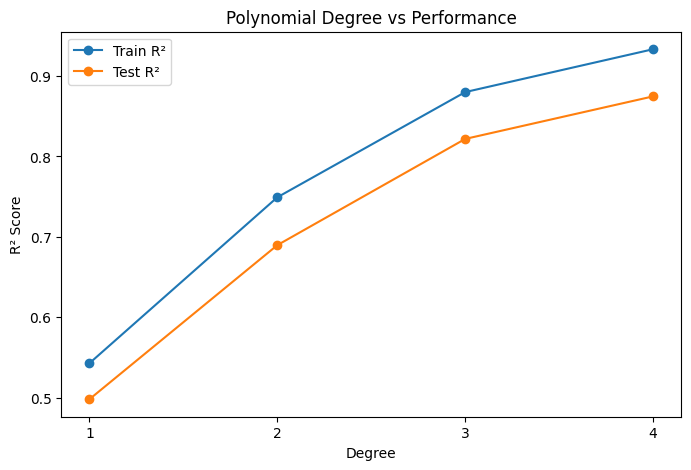

Best polynomial degree: 4


In [48]:
plt.figure(figsize=(8, 5))
plt.plot(poly_results_df['Degree'], poly_results_df['Train_R2'], marker='o', label='Train R²')
plt.plot(poly_results_df['Degree'], poly_results_df['Test_R2'], marker='o', label='Test R²')
plt.title('Polynomial Degree vs Performance')
plt.xlabel('Degree')
plt.ylabel('R² Score')
plt.xticks([1, 2, 3, 4])
plt.legend()
plt.show()

best_degree = int(poly_results_df.sort_values(['Test_R2', 'Train_Test_Gap'], ascending=[False, True]).iloc[0]['Degree'])
print('Best polynomial degree:', best_degree)



###  regularization

In [49]:
alphas = np.logspace(-3, 3, 7)
regularization_results = []
ridge_models = {}
lasso_models = {}

for alpha in alphas:
    ridge_pipeline = Pipeline(steps=[
        ('preprocess', make_polynomial_preprocessor(best_degree)),
        ('model', Ridge(alpha=alpha, random_state=RANDOM_STATE))
    ])
    ridge_pipeline.fit(X_reg_train, y_reg_train)
    regularization_results.append([
        'Ridge', alpha,
        rmse_score(y_reg_train, ridge_pipeline.predict(X_reg_train)),
        rmse_score(y_reg_test, ridge_pipeline.predict(X_reg_test))
    ])
    ridge_models[alpha] = ridge_pipeline

    lasso_pipeline = Pipeline(steps=[
        ('preprocess', make_polynomial_preprocessor(best_degree)),
        ('model', Lasso(alpha=alpha, max_iter=10000, random_state=RANDOM_STATE))
    ])
    lasso_pipeline.fit(X_reg_train, y_reg_train)
    regularization_results.append([
        'Lasso', alpha,
        rmse_score(y_reg_train, lasso_pipeline.predict(X_reg_train)),
        rmse_score(y_reg_test, lasso_pipeline.predict(X_reg_test))
    ])
    lasso_models[alpha] = lasso_pipeline

regularization_df = pd.DataFrame(regularization_results, columns=['Model', 'Alpha', 'Train_RMSE', 'Test_RMSE'])
regularization_df


,Model,Alpha,Train_RMSE,Test_RMSE
0,Ridge,0.001,1.844189,2.755551
1,Lasso,0.001,1.889350,2.635357
2,Ridge,0.010,1.844169,2.754474
3,Lasso,0.010,2.040637,2.676673
4,Ridge,0.100,1.846983,2.765874
5,Lasso,0.100,2.121909,2.772321
6,Ridge,1.000,1.860856,2.724935
7,Lasso,1.000,2.284924,2.980140
8,Ridge,10.000,1.913819,2.649996
9,Lasso,10.000,4.342360,5.095877


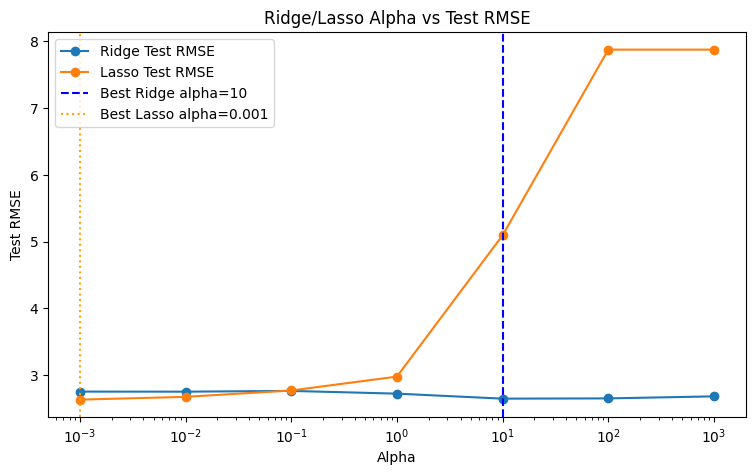

Best Ridge:


,Model,Alpha,Train_RMSE,Test_RMSE
8,Ridge,10.0,1.913819,2.649996


Best Lasso:


,Model,Alpha,Train_RMSE,Test_RMSE
1,Lasso,0.001,1.88935,2.635357


In [50]:
plt.figure(figsize=(9, 5))
for model_name in ['Ridge', 'Lasso']:
    sub = regularization_df[regularization_df['Model'] == model_name]
    plt.plot(sub['Alpha'], sub['Test_RMSE'], marker='o', label=f'{model_name} Test RMSE')

best_ridge_row = regularization_df[regularization_df['Model'] == 'Ridge'].sort_values('Test_RMSE').iloc[0]
best_lasso_row = regularization_df[regularization_df['Model'] == 'Lasso'].sort_values('Test_RMSE').iloc[0]
plt.axvline(best_ridge_row['Alpha'], linestyle='--', label=f"Best Ridge alpha={best_ridge_row['Alpha']:.3g}", color='blue')
plt.axvline(best_lasso_row['Alpha'], linestyle=':', label=f"Best Lasso alpha={best_lasso_row['Alpha']:.3g}" , color='orange')
plt.xscale('log')
plt.title('Ridge/Lasso Alpha vs Test RMSE')
plt.xlabel('Alpha')
plt.ylabel('Test RMSE')
plt.legend()
plt.show()

print('Best Ridge:')
display(best_ridge_row.to_frame().T)
print('Best Lasso:')
display(best_lasso_row.to_frame().T)


In [51]:
best_ridge_alpha = best_ridge_row['Alpha']
best_lasso_alpha = best_lasso_row['Alpha']
best_ridge_model = ridge_models[best_ridge_alpha]
best_lasso_model = lasso_models[best_lasso_alpha]

ridge_vs_lasso_metrics = pd.concat([
    regression_metrics(best_ridge_model, X_reg_train, X_reg_test, y_reg_train, y_reg_test, f'Ridge alpha={best_ridge_alpha:.3g}'),
    regression_metrics(best_lasso_model, X_reg_train, X_reg_test, y_reg_train, y_reg_test, f'Lasso alpha={best_lasso_alpha:.3g}')
], ignore_index=True)
ridge_vs_lasso_metrics


,Model,Split,MAE,MSE,RMSE,R2
0,Ridge alpha=10,Train,0.712733,3.662702,1.913819,0.927205
1,Ridge alpha=10,Test,0.789523,7.022479,2.649996,0.886792
2,Lasso alpha=0.001,Train,0.707594,3.569645,1.889350,0.929054
3,Lasso alpha=0.001,Test,0.765542,6.945106,2.635357,0.888040


In [ ]:
# Function to extract feature names from ColumnTransformer, handling pipelines and one-hot encoding
def get_feature_names_from_column_transformer(column_transformer):
    names_out = []
    for name, transformer, cols in column_transformer.transformers_:
        if name == 'remainder' and transformer == 'drop':
            continue
        if hasattr(transformer, 'named_steps'):     # If its a Pipeline, get the last steps feature names
            last_step = list(transformer.named_steps.values())[-1] # Get the last step of the pipeline
            if hasattr(last_step, 'get_feature_names_out'): # If the last step has get_feature_names_out, use it to get feature names
                try:
                    names = last_step.get_feature_names_out(cols)
                except Exception:
                    names = last_step.get_feature_names_out()
            else:
                names = cols
        elif hasattr(transformer, 'get_feature_names_out'):
            names = transformer.get_feature_names_out(cols)
        else:
            names = cols
        names_out.extend(list(names))
    return np.array(names_out)

lasso_preprocessor = best_lasso_model.named_steps['preprocess']
lasso_coefficients = best_lasso_model.named_steps['model'].coef_
feature_names = get_feature_names_from_column_transformer(lasso_preprocessor)
zero_mask = np.isclose(lasso_coefficients, 0)

print(f'Lasso zeroed out {zero_mask.sum()} out of {len(lasso_coefficients)} features.')
print('First 30 zeroed features:')
display(pd.DataFrame({'zeroed_feature': feature_names[zero_mask]}).head(30))
print('Top non-zero features:')
display(pd.DataFrame({
    'feature': feature_names[~zero_mask],
    'coefficient': lasso_coefficients[~zero_mask]
}).sort_values('coefficient', key=lambda s: np.abs(s), ascending=False).head(20))


Lasso zeroed out 1106 out of 1245 features.
First 30 zeroed features:


,zeroed_feature
0,Age Overall_Rating
1,Overall_Rating Total_Stats Score
2,Overall_Rating^2 Future Potential
3,Overall_Rating Future Potential^2
4,Age Overall_Rating^2 Future Potential
5,Age Overall_Rating Future Potential^2
6,Overall_Rating Future Potential Total_Stats Sc...
7,Country_Afghanistan
8,Country_Albania
9,Country_Algeria


Top non-zero features:


,feature,coefficient
126,Team_Netherlands,-21.995577
112,Team_Croatia,-12.665138
111,Team_Colombia,-9.209228
122,Team_Manchester City,8.931161
125,Team_Mexico,-6.634272
100,Position_RF,-5.306328
135,Team_Ukraine,-4.787444
113,Team_Côte d'Ivoire,-4.419677
5,Age Future Potential,2.281893
13,Age^2 Overall_Rating,2.063207


# Task 5: Model 2 — Logistic Regression

The classifier predicts `Performance_Tier`. `Overall_Rating` is excluded from the features.


In [53]:
numeric_preprocess_clf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('outlier_clipper', IQR_CLIP(factor=1.5)),
    ('scaler', StandardScaler())
])

preprocess_classification = ColumnTransformer(transformers=[
    ('num', numeric_preprocess_clf, classification_numeric_features),
    ('cat', categorical_preprocess, classification_categorical_features)
])

logistic_baseline = Pipeline(steps=[
    ('preprocess', preprocess_classification),
    ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

logistic_baseline.fit(X_clf_train, y_clf_train)
y_log_pred = logistic_baseline.predict(X_clf_test)
print(classification_report(y_clf_test, y_log_pred, zero_division=0)) # zero_division=0 to handle any potential zero division in precision/recall


              precision    recall  f1-score   support

       Elite       0.91      0.92      0.92       940
        High       0.82      0.81      0.82       859
         Low       0.91      0.92      0.92      1114
         Mid       0.83      0.83      0.83      1021

    accuracy                           0.87      3934
   macro avg       0.87      0.87      0.87      3934
weighted avg       0.87      0.87      0.87      3934



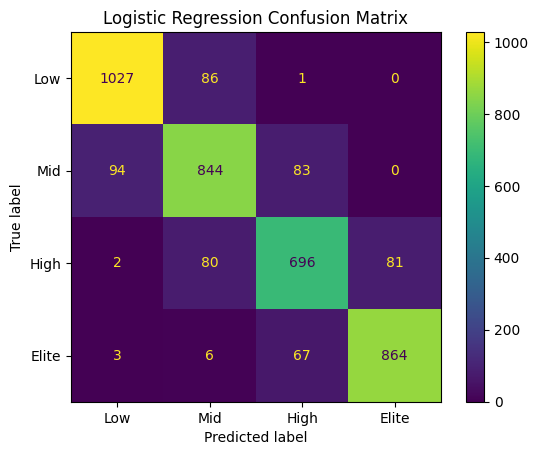

Diagonal cells are correct predictions. Off-diagonal cells are classification errors.


In [54]:
cm_log = confusion_matrix(y_clf_test, y_log_pred, labels=labels_order)
ConfusionMatrixDisplay(cm_log, display_labels=labels_order).plot(values_format='d')
plt.title('Logistic Regression Confusion Matrix')
plt.show()
print('Diagonal cells are correct predictions. Off-diagonal cells are classification errors.')


In [55]:
C_values = np.logspace(-3, 3, 7)
logistic_c_results = []
for C in C_values:
    model = Pipeline(steps=[
        ('preprocess', preprocess_classification),
        ('model', LogisticRegression(C=C, max_iter=2000, random_state=RANDOM_STATE))
    ])
    model.fit(X_clf_train, y_clf_train)
    logistic_c_results.append([
        C,
        accuracy_score(y_clf_train, model.predict(X_clf_train)),
        accuracy_score(y_clf_test, model.predict(X_clf_test))
    ])

logistic_c_df = pd.DataFrame(logistic_c_results, columns=['C', 'Train_Accuracy', 'Test_Accuracy'])
logistic_c_df


,C,Train_Accuracy,Test_Accuracy
0,0.001,0.795970,0.782664
1,0.010,0.856099,0.846975
2,0.100,0.884828,0.864769
3,1.000,0.918261,0.872140
4,10.000,0.941397,0.865785
5,100.000,0.948961,0.857143
6,1000.000,0.950168,0.853584


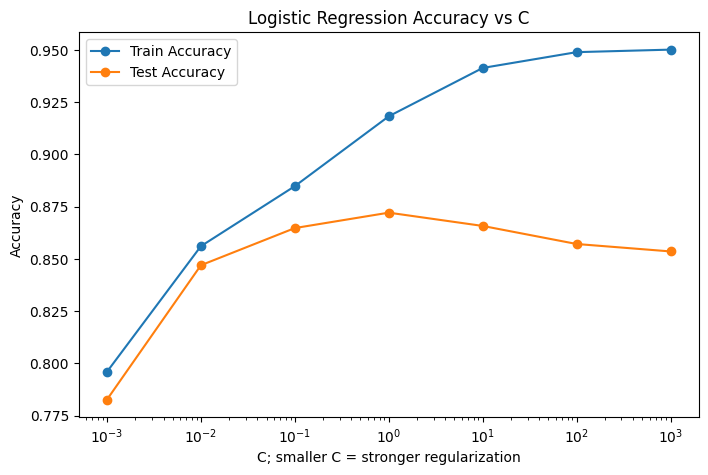

Best C: 1.0


In [56]:
plt.figure(figsize=(8, 5))
plt.plot(logistic_c_df['C'], logistic_c_df['Train_Accuracy'], marker='o', label='Train Accuracy')
plt.plot(logistic_c_df['C'], logistic_c_df['Test_Accuracy'], marker='o', label='Test Accuracy')
plt.xscale('log')
plt.title('Logistic Regression Accuracy vs C')
plt.xlabel('C; smaller C = stronger regularization')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

best_C = logistic_c_df.sort_values('Test_Accuracy', ascending=False).iloc[0]['C']
print('Best C:', best_C)


In [57]:
log_l1 = Pipeline(steps=[
    ('preprocess', preprocess_classification),
    ('model', LogisticRegression(C=best_C, penalty='l1', solver='saga', max_iter=3000, random_state=RANDOM_STATE))
])
log_l2 = Pipeline(steps=[
    ('preprocess', preprocess_classification),
    ('model', LogisticRegression(C=best_C, penalty='l2', solver='lbfgs', max_iter=3000, random_state=RANDOM_STATE))
])

log_l1.fit(X_clf_train, y_clf_train)
log_l2.fit(X_clf_train, y_clf_train)
l1_pred = log_l1.predict(X_clf_test)
l2_pred = log_l2.predict(X_clf_test)

log_reg_comparison = pd.DataFrame({
    'Penalty': ['L1', 'L2'],
    'Test_Accuracy': [accuracy_score(y_clf_test, l1_pred), accuracy_score(y_clf_test, l2_pred)],
    'Weighted_F1': [
        precision_recall_fscore_support(y_clf_test, l1_pred, average='weighted', zero_division=0)[2],
        precision_recall_fscore_support(y_clf_test, l2_pred, average='weighted', zero_division=0)[2]
    ]
})
log_reg_comparison


,Penalty,Test_Accuracy,Weighted_F1
0,L1,0.880783,0.880728
1,L2,0.872140,0.871930


# Task 6: Model 3 — Naïve Bayes Classification

Required variants:
- GaussianNB on numerical features only: `Age`, `Future Potential`, `Total_Stats Score`
- BernoulliNB on binary/OHE features
- ComplementNB on non-negative features

GaussianNB is tested with and without scaling.


In [58]:
gaussian_numeric_features = ['Age', 'Future Potential', 'Total_Stats Score']
X_gnb_train = X_clf_train[gaussian_numeric_features].copy()
X_gnb_test = X_clf_test[gaussian_numeric_features].copy()

gnb_no_scaling = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('outlier_clipper', IQR_CLIP(factor=1.5)),
    ('model', GaussianNB())
])
gnb_scaled = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('outlier_clipper', IQR_CLIP(factor=1.5)),
    ('scaler', StandardScaler()),
    ('model', GaussianNB())
])

gnb_no_scaling.fit(X_gnb_train, y_clf_train)
gnb_scaled.fit(X_gnb_train, y_clf_train)
gnb_no_scaling_pred = gnb_no_scaling.predict(X_gnb_test)
gnb_scaled_pred = gnb_scaled.predict(X_gnb_test)

print('GaussianNB without scaling:')
print(classification_report(y_clf_test, gnb_no_scaling_pred, zero_division=0))
print('GaussianNB with scaling:')
print(classification_report(y_clf_test, gnb_scaled_pred, zero_division=0))
print('Scaling usually has limited effect on GaussianNB because it estimates class means and variances for each feature.')


GaussianNB without scaling:
              precision    recall  f1-score   support

       Elite       0.86      0.80      0.83       940
        High       0.62      0.53      0.57       859
         Low       0.82      0.81      0.81      1114
         Mid       0.59      0.70      0.64      1021

    accuracy                           0.72      3934
   macro avg       0.72      0.71      0.71      3934
weighted avg       0.72      0.72      0.72      3934

GaussianNB with scaling:
              precision    recall  f1-score   support

       Elite       0.86      0.80      0.83       940
        High       0.62      0.53      0.57       859
         Low       0.82      0.81      0.81      1114
         Mid       0.59      0.70      0.64      1021

    accuracy                           0.72      3934
   macro avg       0.72      0.71      0.71      3934
weighted avg       0.72      0.72      0.72      3934

Scaling usually has limited effect on GaussianNB because it estimates class m

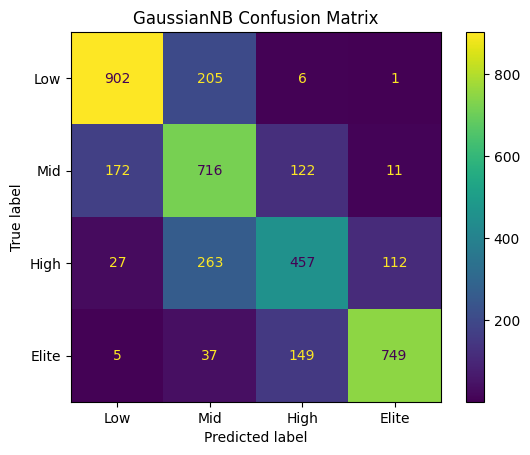

In [59]:
cm_gnb = confusion_matrix(y_clf_test, gnb_no_scaling_pred, labels=labels_order)
ConfusionMatrixDisplay(cm_gnb, display_labels=labels_order).plot(values_format='d')
plt.title('GaussianNB Confusion Matrix')
plt.show()


              precision    recall  f1-score   support

       Elite       0.74      0.85      0.80       940
        High       0.61      0.42      0.50       859
         Low       0.76      0.81      0.78      1114
         Mid       0.61      0.64      0.62      1021

    accuracy                           0.69      3934
   macro avg       0.68      0.68      0.68      3934
weighted avg       0.68      0.69      0.68      3934



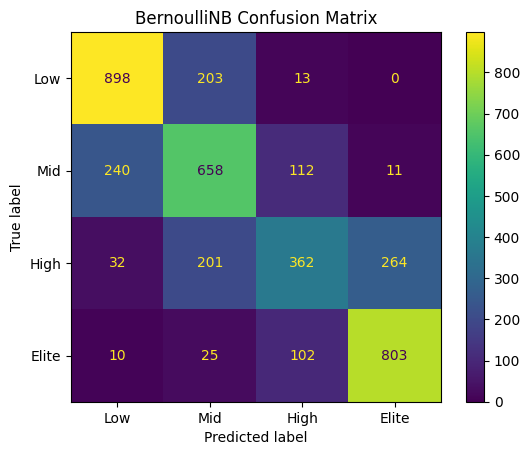

In [ ]:
# bernoulli is designed for binary features
bernoulli_numeric_preprocess = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('outlier_clipper', IQR_CLIP(factor=1.5)),
    ('scaler', StandardScaler()),
    ('binarizer', Binarizer(threshold=0.0)) # Binarize after scaling to create binary features for BernoulliNB after scaling
])
preprocess_bernoulli = ColumnTransformer(transformers=[
    ('num_bin', bernoulli_numeric_preprocess, classification_numeric_features),
    ('cat', categorical_preprocess, classification_categorical_features)
])
bernoulli_nb = Pipeline(steps=[
    ('preprocess', preprocess_bernoulli),
    ('model', BernoulliNB())
])
bernoulli_nb.fit(X_clf_train, y_clf_train)
bernoulli_pred = bernoulli_nb.predict(X_clf_test)
print(classification_report(y_clf_test, bernoulli_pred, zero_division=0))

cm_bernoulli = confusion_matrix(y_clf_test, bernoulli_pred, labels=labels_order)
ConfusionMatrixDisplay(cm_bernoulli, display_labels=labels_order).plot(values_format='d')
plt.title('BernoulliNB Confusion Matrix')
plt.show()


              precision    recall  f1-score   support

       Elite       0.59      0.80      0.68       940
        High       0.37      0.25      0.30       859
         Low       0.58      0.71      0.64      1114
         Mid       0.45      0.31      0.37      1021

    accuracy                           0.53      3934
   macro avg       0.50      0.52      0.50      3934
weighted avg       0.50      0.53      0.51      3934



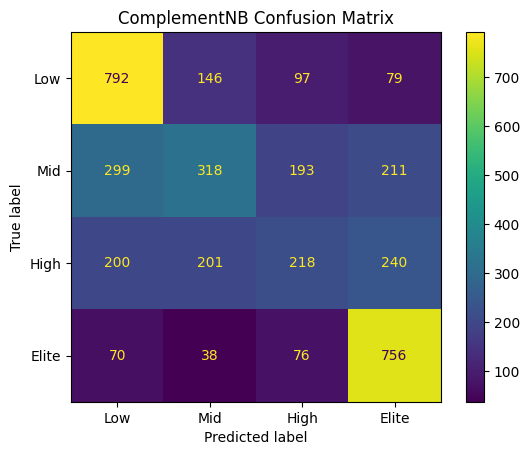

In [61]:
complement_numeric_preprocess = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('outlier_clipper', IQR_CLIP(factor=1.5)),
    ('minmax', MinMaxScaler()) # we use MinMaxScaler to ensure all values are in the [0, 1] range.
])
preprocess_complement = ColumnTransformer(transformers=[
    ('num_nonnegative', complement_numeric_preprocess, classification_numeric_features),
    ('cat', categorical_preprocess, classification_categorical_features)
])
complement_nb = Pipeline(steps=[
    ('preprocess', preprocess_complement),
    ('model', ComplementNB())
])
complement_nb.fit(X_clf_train, y_clf_train)
complement_pred = complement_nb.predict(X_clf_test)
print(classification_report(y_clf_test, complement_pred, zero_division=0))

cm_complement = confusion_matrix(y_clf_test, complement_pred, labels=labels_order)
ConfusionMatrixDisplay(cm_complement, display_labels=labels_order).plot(values_format='d')
plt.title('ComplementNB Confusion Matrix')
plt.show()


In [62]:
nb_comparison = pd.DataFrame({
    'Model': ['GaussianNB no scaling', 'GaussianNB scaled', 'BernoulliNB', 'ComplementNB'],
    'Accuracy': [
        accuracy_score(y_clf_test, gnb_no_scaling_pred),
        accuracy_score(y_clf_test, gnb_scaled_pred),
        accuracy_score(y_clf_test, bernoulli_pred),
        accuracy_score(y_clf_test, complement_pred)
    ],
    'Weighted_F1': [
        precision_recall_fscore_support(y_clf_test, gnb_no_scaling_pred, average='weighted', zero_division=0)[2],
        precision_recall_fscore_support(y_clf_test, gnb_scaled_pred, average='weighted', zero_division=0)[2],
        precision_recall_fscore_support(y_clf_test, bernoulli_pred, average='weighted', zero_division=0)[2],
        precision_recall_fscore_support(y_clf_test, complement_pred, average='weighted', zero_division=0)[2]
    ]
}).sort_values('Accuracy', ascending=False)
nb_comparison


,Model,Accuracy,Weighted_F1
0,GaussianNB no scaling,0.717844,0.718586
1,GaussianNB scaled,0.717844,0.718586
2,BernoulliNB,0.691662,0.683058
3,ComplementNB,0.529741,0.505250


### Naïve Bayes justification

GaussianNB is conceptually the most appropriate variant for the FIFA dataset because important predictors such as `Age`, `Future Potential`, and `Total_Stats Score` are continuous numerical features. BernoulliNB is designed for binary features, so it is less natural for this dataset unless features are binarized. ComplementNB is designed for non-negative count-like features and is common in text classification, so it is not the most natural fit for FIFA player attributes. The final choice should still be supported by the performance table above.


# Task 7: Model Evaluation with Cross-Validation

We use:
- 5-fold K-Fold CV for regression
- 5-fold StratifiedKFold CV for classification


In [63]:
# A. Regression CV
if best_ridge_row['Test_RMSE'] <= best_lasso_row['Test_RMSE']:
    best_regression_name = 'Ridge'
    best_regression_model = Pipeline(steps=[
        ('preprocess', make_polynomial_preprocessor(best_degree)),
        ('model', Ridge(alpha=best_ridge_alpha, random_state=RANDOM_STATE))
    ])
else:
    best_regression_name = 'Lasso'
    best_regression_model = Pipeline(steps=[
        ('preprocess', make_polynomial_preprocessor(best_degree)),
        ('model', Lasso(alpha=best_lasso_alpha, max_iter=10000, random_state=RANDOM_STATE))
    ])

neg_rmse_scorer = make_scorer(lambda y_true, y_pred: -rmse_score(y_true, y_pred))
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rmse_scores = -cross_val_score(best_regression_model, X_reg, y_reg, cv=kf, scoring=neg_rmse_scorer)
cv_regression_results = pd.DataFrame({'Fold': np.arange(1, 6), 'RMSE': rmse_scores})

print('Best regression model:', best_regression_name)
print('Fold RMSE scores:', rmse_scores)
print(f'Mean RMSE: {rmse_scores.mean():.4f}')
print(f'Std RMSE: {rmse_scores.std():.4f}')
display(cv_regression_results)


Best regression model: Lasso
Fold RMSE scores: [2.63535684 1.75508523 1.67633691 2.69671014 2.06372953]
Mean RMSE: 2.1654
Std RMSE: 0.4292


,Fold,RMSE
0,1,2.635357
1,2,1.755085
2,3,1.676337
3,4,2.696710
4,5,2.063730


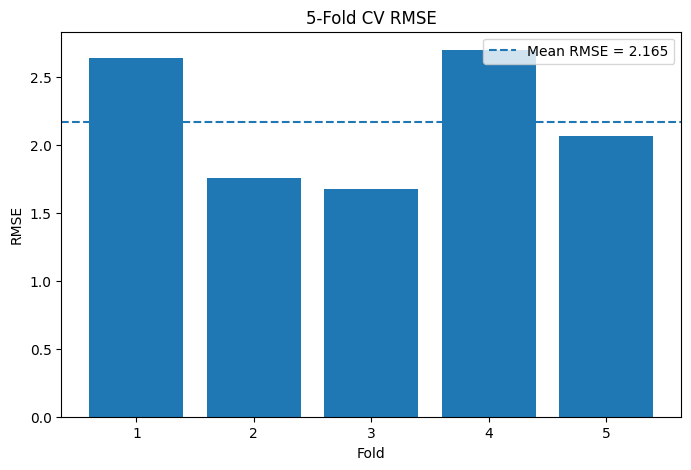

In [64]:
plt.figure(figsize=(8, 5))
plt.bar(cv_regression_results['Fold'], cv_regression_results['RMSE'])
plt.axhline(rmse_scores.mean(), linestyle='--', label=f'Mean RMSE = {rmse_scores.mean():.3f}')
plt.title('5-Fold CV RMSE')
plt.xlabel('Fold')
plt.ylabel('RMSE')
plt.xticks(cv_regression_results['Fold'])
plt.legend()
plt.show()


In [65]:
# B. Classification CV
if log_reg_comparison.sort_values('Test_Accuracy', ascending=False).iloc[0]['Penalty'] == 'L1':
    best_logistic_name = 'Logistic Regression L1'
    best_logistic_cv = Pipeline(steps=[
        ('preprocess', preprocess_classification),
        ('model', LogisticRegression(C=best_C, penalty='l1', solver='saga', max_iter=3000, random_state=RANDOM_STATE))
    ])
else:
    best_logistic_name = 'Logistic Regression L2'
    best_logistic_cv = Pipeline(steps=[
        ('preprocess', preprocess_classification),
        ('model', LogisticRegression(C=best_C, penalty='l2', solver='lbfgs', max_iter=3000, random_state=RANDOM_STATE))
    ])

best_nb_name = nb_comparison.iloc[0]['Model']
if best_nb_name == 'GaussianNB no scaling':
    best_nb_cv = Pipeline(steps=[
        ('select_num', ColumnTransformer([('num', 'passthrough', gaussian_numeric_features)], remainder='drop')),
        ('imputer', SimpleImputer(strategy='median')),
        ('outlier_clipper', IQR_CLIP(factor=1.5)),
        ('model', GaussianNB())
    ])
elif best_nb_name == 'GaussianNB scaled':
    best_nb_cv = Pipeline(steps=[
        ('select_num', ColumnTransformer([('num', 'passthrough', gaussian_numeric_features)], remainder='drop')),
        ('imputer', SimpleImputer(strategy='median')),
        ('outlier_clipper', IQR_CLIP(factor=1.5)),
        ('scaler', StandardScaler()),
        ('model', GaussianNB())
    ])
elif best_nb_name == 'BernoulliNB':
    best_nb_cv = bernoulli_nb
else:
    best_nb_cv = complement_nb

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
logistic_cv_scores = cross_val_score(best_logistic_cv, X_clf, y_clf, cv=skf, scoring='accuracy')
nb_cv_scores = cross_val_score(best_nb_cv, X_clf, y_clf, cv=skf, scoring='accuracy')

classification_cv_df = pd.DataFrame({
    'Fold': np.arange(1, 6),
    best_logistic_name: logistic_cv_scores,
    f'Best NB: {best_nb_name}': nb_cv_scores
})

print(f'{best_logistic_name} mean accuracy: {logistic_cv_scores.mean():.4f}, std: {logistic_cv_scores.std():.4f}')
print(f'{best_nb_name} mean accuracy: {nb_cv_scores.mean():.4f}, std: {nb_cv_scores.std():.4f}')
display(classification_cv_df)


Logistic Regression L1 mean accuracy: 0.8848, std: 0.0034
GaussianNB no scaling mean accuracy: 0.7169, std: 0.0071


,Fold,Logistic Regression L1,Best NB: GaussianNB no scaling
0,1,0.881546,0.708439
1,2,0.880275,0.715557
2,3,0.888380,0.729977
3,4,0.888635,0.715484
4,5,0.885075,0.715230


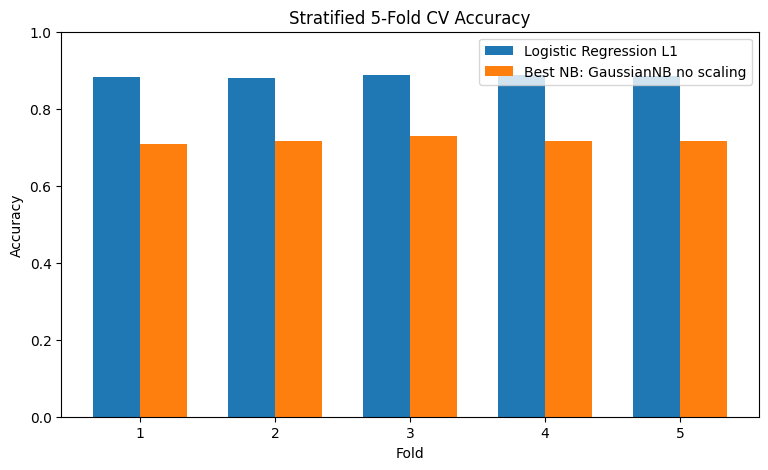

Logistic Regression performs better on average.
Logistic Regression is more stable across folds.


In [66]:
x = np.arange(1, 6)
width = 0.35
plt.figure(figsize=(9, 5))
plt.bar(x - width/2, logistic_cv_scores, width, label=best_logistic_name)
plt.bar(x + width/2, nb_cv_scores, width, label=f'Best NB: {best_nb_name}')
plt.title('Stratified 5-Fold CV Accuracy')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.xticks(x)
plt.ylim(0, 1)
plt.legend()
plt.show()

if logistic_cv_scores.mean() > nb_cv_scores.mean():
    print('Logistic Regression performs better on average.')
else:
    print('Naïve Bayes performs better on average.')

if logistic_cv_scores.std() < nb_cv_scores.std():
    print('Logistic Regression is more stable across folds.')
else:
    print('Naïve Bayes is more stable across folds.')


# Task 8: Analysis and Discussion


In [67]:
best_regression_summary = {
    'best_polynomial_degree': int(best_degree),
    'best_regression_model': best_regression_name,
    'cv_rmse_mean': float(rmse_scores.mean()),
    'cv_rmse_std': float(rmse_scores.std())
}

best_classification_summary = {
    'best_logistic_model': best_logistic_name,
    'best_nb_model': str(best_nb_name),
    'logistic_cv_accuracy_mean': float(logistic_cv_scores.mean()),
    'logistic_cv_accuracy_std': float(logistic_cv_scores.std()),
    'nb_cv_accuracy_mean': float(nb_cv_scores.mean()),
    'nb_cv_accuracy_std': float(nb_cv_scores.std())
}

print('Regression summary:')
print(json.dumps(best_regression_summary, indent=4))
print('\nClassification summary:')
print(json.dumps(best_classification_summary, indent=4))


Regression summary:
{
    "best_polynomial_degree": 4,
    "best_regression_model": "Lasso",
    "cv_rmse_mean": 2.165443728739244,
    "cv_rmse_std": 0.4291917246776222
}

Classification summary:
{
    "best_logistic_model": "Logistic Regression L1",
    "best_nb_model": "GaussianNB no scaling",
    "logistic_cv_accuracy_mean": 0.8847820076262138,
    "logistic_cv_accuracy_std": 0.003425466447853433,
    "nb_cv_accuracy_mean": 0.716937503385055,
    "nb_cv_accuracy_std": 0.00705953758107916
}


## 8.1 Model Comparison

For regression, the best model is selected from the regularized polynomial models using test RMSE and then validated with 5-fold cross-validation. Regularized polynomial regression is usually stronger than the baseline linear model because the relationship between player value and features such as rating, potential, age, and total stats is not perfectly linear. The market value target is also skewed, so extreme high-value players make regression more difficult.

For classification, Logistic Regression and Naïve Bayes are compared using Stratified 5-fold cross-validation. Classification can be easier than regression on this dataset because it predicts broad performance tiers rather than exact market values. Regression is harder because predicting the exact value is sensitive to outliers and skewness.

## 8.2 Regularization Analysis

As alpha increases in Ridge and Lasso, the model becomes more restricted. At first, this can improve test performance by reducing overfitting. If alpha becomes too large, performance gets worse because the model underfits.

Ridge often performs better than Lasso when many one-hot encoded features are present because Ridge shrinks many coefficients smoothly instead of removing them completely. Lasso can zero out features, which helps with feature selection, but it may remove useful categorical information when there are many sparse one-hot columns.


In [68]:
# Save a compact Assignment 2 summary for Assignment 3 comparison.
assignment2_summary = {
    'baseline_linear_regression': baseline_regression_results.to_dict(orient='records'),
    'polynomial_results': poly_results_df.to_dict(orient='records'),
    'regularization_results': regularization_df.to_dict(orient='records'),
    'best_regression': best_regression_summary,
    'logistic_regularization_results': logistic_c_df.to_dict(orient='records'),
    'naive_bayes_comparison': nb_comparison.to_dict(orient='records'),
    'classification_cv': best_classification_summary
}

with open('assignment2_summary.json', 'w') as f:
    json.dump(assignment2_summary, f, indent=4)

print('Saved assignment2_summary.json')


Saved assignment2_summary.json


# Assignment 3 

## Load Assignment 2 Baseline Results



In [69]:
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Regression models
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, VotingRegressor

# Classification models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

# Model selection and validation
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    StratifiedKFold,
    cross_val_score
)

# Pipelines
from sklearn.pipeline import Pipeline

# Regression metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    make_scorer,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [70]:
with open("assignment2_summary.json", "r") as f:
    assignment2_baseline_summary = json.load(f)

print("Assignment 2 baseline summary loaded successfully.")

Assignment 2 baseline summary loaded successfully.


In [71]:
# Display the loaded baseline summary keys

assignment2_baseline_summary.keys()

dict_keys(['baseline_linear_regression', 'polynomial_results', 'regularization_results', 'best_regression', 'logistic_regularization_results', 'naive_bayes_comparison', 'classification_cv'])

In [72]:
# Make a clean copy

fifa_a3 = df.copy()

print("Dataset shape:", fifa_a3.shape)
display(fifa_a3.head())
print('-------------------------------------------')
# Check available columns

print("Columns in the dataset:")
for col in fifa_a3.columns:
    print("-", col)

Dataset shape: (19667, 10)


,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score,Performance_Tier
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660,High
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620,High
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480,Mid
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695,High
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640,High


-------------------------------------------
Columns in the dataset:
- Name
- Country
- Position
- Age
- Overall_Rating
- Future Potential
- Team
- Value Per M$
- Total_Stats Score
- Performance_Tier


In [73]:
# We create performance tiers from Overall_Rating using quartiles.

tier_labels = ["Low", "Mid", "High", "Elite"]

fifa_a3["Performance_Tier"] = pd.qcut(
    fifa_a3["Overall_Rating"],
    q=4,           # quartiles (25% each) 
    labels=tier_labels,
    duplicates="drop"     # Handle any duplicate edges by dropping them
)

print("Performance tier distribution:")
display(fifa_a3["Performance_Tier"].value_counts().sort_index())

Performance tier distribution:


Performance_Tier
Low      5568
Mid      5102
High     4297
Elite    4700
Name: count, dtype: int64

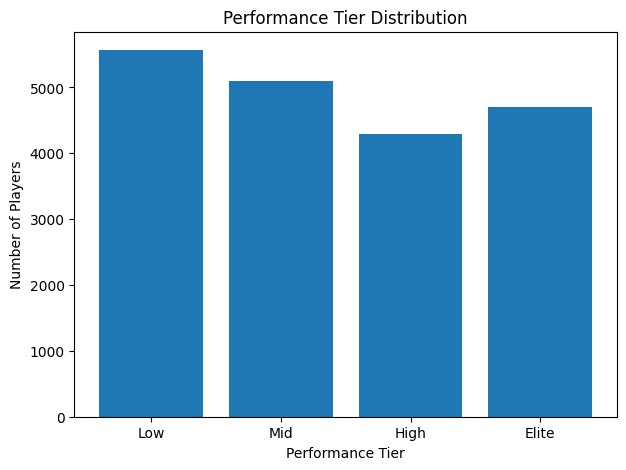

In [74]:
tier_counts = fifa_a3["Performance_Tier"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(tier_counts.index, tier_counts.values)
plt.title("Performance Tier Distribution")
plt.xlabel("Performance Tier")
plt.ylabel("Number of Players")
plt.xticks(rotation=0)
plt.show()

In [75]:
# Define Targets

# Regression target
y_reg = fifa_a3["Value Per M$"]


y_reg_log = np.log1p(y_reg)

# Classification target: performance tier
y_clf = fifa_a3["Performance_Tier"]

print("Regression target example:")
display(y_reg.head())

print("Log-transformed regression target example:")
display(y_reg_log.head())

print("Classification target example:")
display(y_clf.head())

Regression target example:


0    0.65
1    0.35
2    0.20
3    0.50
4    0.40
Name: Value Per M$, dtype: float64

Log-transformed regression target example:


0    0.500775
1    0.300105
2    0.182322
3    0.405465
4    0.336472
Name: Value Per M$, dtype: float64

Classification target example:


0    High
1    High
2     Mid
3    High
4    High
Name: Performance_Tier, dtype: category
Categories (4, object): ['Low' < 'Mid' < 'High' < 'Elite']

In [76]:
# Define Feature Sets
# Columns that should never be used as features
general_drop_cols = [
    "Name",
    "Value Per M$",
    "Performance_Tier"
]

# Classification CANNOT use Overall_Rating because the tier was created from it.

regression_drop_cols = general_drop_cols.copy()

classification_drop_cols = general_drop_cols + [
    "Overall_Rating"
]

# Create regression features
X_reg = fifa_a3.drop(columns=regression_drop_cols, errors="ignore")

# Create classification features
X_clf = fifa_a3.drop(columns=classification_drop_cols, errors="ignore")

print("Regression features:")
print(X_reg.columns.tolist())

print("\nClassification features:")
print(X_clf.columns.tolist())

Regression features:
['Country', 'Position', 'Age', 'Overall_Rating', 'Future Potential', 'Team', 'Total_Stats Score']

Classification features:
['Country', 'Position', 'Age', 'Future Potential', 'Team', 'Total_Stats Score']


In [77]:
# Identify Numerical and Categorical Columns

reg_num_cols = X_reg.select_dtypes(include=["int64", "float64"]).columns.tolist()
reg_cat_cols = X_reg.select_dtypes(include=["object", "category"]).columns.tolist()

clf_num_cols = X_clf.select_dtypes(include=["int64", "float64"]).columns.tolist()
clf_cat_cols = X_clf.select_dtypes(include=["object", "category"]).columns.tolist()

print("Regression numerical columns:", reg_num_cols)
print("Regression categorical columns:", reg_cat_cols)

print("\nClassification numerical columns:", clf_num_cols)
print("Classification categorical columns:", clf_cat_cols)

Regression numerical columns: ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']
Regression categorical columns: ['Country', 'Position', 'Team']

Classification numerical columns: ['Age', 'Future Potential', 'Total_Stats Score']
Classification categorical columns: ['Country', 'Position', 'Team']


In [78]:
# Train/Test Split

# Regression split
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg_log,
    test_size=0.2,
    random_state=42
)

# Classification split
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

print("Regression train shape:", X_reg_train.shape)
print("Regression test shape:", X_reg_test.shape)

print("\nClassification train shape:", X_clf_train.shape)
print("Classification test shape:", X_clf_test.shape)

Regression train shape: (15733, 7)
Regression test shape: (3934, 7)

Classification train shape: (15733, 6)
Classification test shape: (3934, 6)


In [79]:

try:
    onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

# Numerical preprocessing:

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing:

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot_encoder)
])

# Regression preprocessor
regression_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, reg_num_cols),
        ("cat", categorical_transformer, reg_cat_cols)
    ],
    remainder="drop"
)

# Classification preprocessor
classification_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, clf_num_cols),
        ("cat", categorical_transformer, clf_cat_cols)
    ],
    remainder="drop"
)

print("Regression and classification preprocessors created successfully.")

Regression and classification preprocessors created successfully.


In [80]:
# Test Preprocessing Output

X_reg_train_processed = regression_preprocessor.fit_transform(X_reg_train)
X_clf_train_processed = classification_preprocessor.fit_transform(X_clf_train)

print("Processed regression training shape:", X_reg_train_processed.shape)
print("Processed classification training shape:", X_clf_train_processed.shape)

Processed regression training shape: (15733, 1180)
Processed classification training shape: (15733, 1174)


# The Model Selection
Advanced Regression Models

In this step, we move beyond the baseline regression models from Assignment 2 and implement three diverse advanced regression approaches:

1. KNN Regressor — instance-based learning
2. SVM Regression — kernel-based learning
3. Random Forest Regressor — tree-based ensemble learning

These models are selected because the FIFA dataset may contain nonlinear relationships between player attributes and market value. For example, a small increase in rating or potential may lead to a much larger increase in market value for elite players. Therefore, more flexible models may perform better than simple linear models.

## Error Diagnosis

In [81]:
# evaluation function for regression 

def evaluate_regression_model(model, X_train, X_test, y_train, y_test, model_name):

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)
    
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    return {
        "Model": model_name,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train R2": train_r2,
        "Test R2": test_r2,
        "Train-Test R2 Gap": train_r2 - test_r2
    }

### Model 1: KNN Regressor

In [82]:
knn_reg_pipeline = Pipeline(steps=[
    ("preprocessor", regression_preprocessor),
    ("model", KNeighborsRegressor())
])

knn_reg_param_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11],
    "model__weights": ["uniform", "distance"], # uniform = all neighbors contribute equally, distance = closer neighbors contribute more
    "model__p": [1, 2]  # p=1 is Manhattan distance, p=2 is Euclidean distance
}

knn_reg_grid = GridSearchCV(
    estimator=knn_reg_pipeline,
    param_grid=knn_reg_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

knn_reg_grid.fit(X_reg_train, y_reg_train)

best_knn_reg = knn_reg_grid.best_estimator_

print("Best KNN Regressor Parameters:")
print(knn_reg_grid.best_params_)

print("Best KNN Regressor CV R2:")
print(knn_reg_grid.best_score_)

Best KNN Regressor Parameters:
{'model__n_neighbors': 11, 'model__p': 2, 'model__weights': 'distance'}
Best KNN Regressor CV R2:
0.9335579344918324


### Model 2: SVM Regression

In [ ]:
svm_reg_pipeline = Pipeline(steps=[
    ("preprocessor", regression_preprocessor),
    ("model", SVR(cache_size=1000, max_iter=5000))
])


svm_reg_param_grid = {
    "model__kernel": ["rbf"],
    "model__C": [1, 10],
    "model__gamma": ["scale"],
    "model__epsilon": [0.1]
}

svm_reg_grid = GridSearchCV(
    estimator=svm_reg_pipeline,
    param_grid=svm_reg_param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=1 # to show progress since SVM can be slow
)

svm_reg_grid.fit(X_reg_train, y_reg_train)

best_svm_reg = svm_reg_grid.best_estimator_

print("Best SVM Regression Parameters:")
print(svm_reg_grid.best_params_)

print("Best SVM Regression CV R2:")
print(svm_reg_grid.best_score_)

Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best SVM Regression Parameters:
{'model__C': 10, 'model__epsilon': 0.1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best SVM Regression CV R2:
0.9670278008564637


### Model 3: Random Forest Regressor

In [84]:
rf_reg_pipeline = Pipeline(steps=[
    ("preprocessor", regression_preprocessor),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

rf_reg_param_grid = {
    "model__n_estimators": [100], # 100 decision trees
    "model__max_depth": [None, 20],  
    "model__min_samples_split": [2, 5],  # minimum number of samples required to split an internal node
    "model__min_samples_leaf": [1]   
}

rf_reg_grid = GridSearchCV(
    estimator=rf_reg_pipeline,
    param_grid=rf_reg_param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

rf_reg_grid.fit(X_reg_train, y_reg_train)

best_rf_reg = rf_reg_grid.best_estimator_

print("Best Random Forest Regressor Parameters:")
print(rf_reg_grid.best_params_)

print("\nBest Random Forest Regressor CV R2:")
print(rf_reg_grid.best_score_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best Random Forest Regressor Parameters:
{'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Best Random Forest Regressor CV R2:
0.9567470055262003


### Evaluate All Models 

In [85]:
advanced_regression_results = []

advanced_regression_results.append(
    evaluate_regression_model(
        best_knn_reg,
        X_reg_train,
        X_reg_test,
        y_reg_train,
        y_reg_test,
        "KNN Regressor"
    )
)

advanced_regression_results.append(
    evaluate_regression_model(
        best_svm_reg,
        X_reg_train,
        X_reg_test,
        y_reg_train,
        y_reg_test,
        "SVM Regression"
    )
)

advanced_regression_results.append(
    evaluate_regression_model(
        best_rf_reg,
        X_reg_train,
        X_reg_test,
        y_reg_train,
        y_reg_test,
        "Random Forest Regressor"
    )
)

advanced_regression_results_df = pd.DataFrame(advanced_regression_results)

display(advanced_regression_results_df)

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,Train-Test R2 Gap
0,KNN Regressor,4.056439e-09,0.104935,2.400312e-08,0.177851,1.000000,0.946082,0.053918
1,SVM Regression,5.226107e-02,0.070572,6.228304e-02,0.121627,0.993098,0.974784,0.018314
2,Random Forest Regressor,1.606279e-02,0.036204,5.434401e-02,0.122551,0.994745,0.974399,0.020346


### Cross-Validation Stability

In [86]:
reg_cv = KFold(n_splits=5, shuffle=True, random_state=42)

advanced_regression_cv_results = []

regression_models = {
    "KNN Regressor": best_knn_reg,
    "SVM Regression": best_svm_reg,
    "Random Forest Regressor": best_rf_reg
}

for model_name, model in regression_models.items():
    cv_r2_scores = cross_val_score(
        model,
        X_reg,
        y_reg_log,
        cv=reg_cv,
        scoring="r2",
        n_jobs=-1
    )
    
    advanced_regression_cv_results.append({
        "Model": model_name,
        "CV R2 Mean": cv_r2_scores.mean(),
        "CV R2 Std": cv_r2_scores.std(),
        "Individual Fold R2 Scores": cv_r2_scores
    })

advanced_regression_cv_df = pd.DataFrame(advanced_regression_cv_results)

display(advanced_regression_cv_df)

,Model,CV R2 Mean,CV R2 Std,Individual Fold R2 Scores
0,KNN Regressor,0.937282,0.008181,"[0.9460821884675814, 0.9376186296755553, 0.945..."
1,SVM Regression,0.971343,0.005111,"[0.9747835635588885, 0.9692770398117392, 0.979..."
2,Random Forest Regressor,0.961691,0.011824,"[0.9749067491798729, 0.9544806726104524, 0.976..."


In [87]:
# Select Best Advanced Regression Model

best_advanced_regression_row = advanced_regression_results_df.sort_values(
    by="Test R2",
    ascending=False
).iloc[0]

best_advanced_regression_name = best_advanced_regression_row["Model"]

if best_advanced_regression_name == "KNN Regressor":
    best_advanced_regression_model = best_knn_reg
    best_advanced_regression_params = knn_reg_grid.best_params_

elif best_advanced_regression_name == "SVM Regression":
    best_advanced_regression_model = best_svm_reg
    best_advanced_regression_params = svm_reg_grid.best_params_

else:
    best_advanced_regression_model = best_rf_reg
    best_advanced_regression_params = rf_reg_grid.best_params_

print("Best Advanced Regression Model:")
print(best_advanced_regression_name)

print("\nBest Advanced Regression Parameters:")
print(best_advanced_regression_params)

display(best_advanced_regression_row)

Best Advanced Regression Model:
SVM Regression

Best Advanced Regression Parameters:
{'model__C': 10, 'model__epsilon': 0.1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}


Model                SVM Regression
Train MAE                  0.052261
Test MAE                   0.070572
Train RMSE                 0.062283
Test RMSE                  0.121627
Train R2                   0.993098
Test R2                    0.974784
Train-Test R2 Gap          0.018314
Name: 1, dtype: object

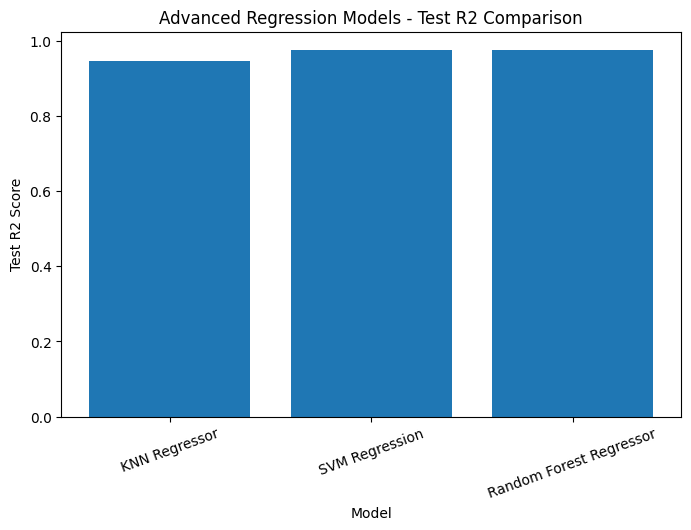

In [88]:
# Plot Advanced Regression Model Comparison

plt.figure(figsize=(8, 5))
plt.bar(
    advanced_regression_results_df["Model"],
    advanced_regression_results_df["Test R2"]
)
plt.title("Advanced Regression Models - Test R2 Comparison")
plt.xlabel("Model")
plt.ylabel("Test R2 Score")
plt.xticks(rotation=20)
plt.show()

In [89]:
# Bias vs Variance Diagnosis


def diagnose_bias_variance(row):
    train_r2 = row["Train R2"]
    test_r2 = row["Test R2"]
    gap = row["Train-Test R2 Gap"]
    
    if train_r2 < 0.6 and test_r2 < 0.6:
        return "Possible high bias / underfitting"
    elif gap > 0.15:
        return "Possible high variance / overfitting"
    else:
        return "Relatively stable generalization"

advanced_regression_results_df["Diagnosis"] = advanced_regression_results_df.apply(
    diagnose_bias_variance,
    axis=1
)

display(advanced_regression_results_df[
    ["Model", "Train R2", "Test R2", "Train-Test R2 Gap", "Diagnosis"]
])

,Model,Train R2,Test R2,Train-Test R2 Gap,Diagnosis
0,KNN Regressor,1.000000,0.946082,0.053918,Relatively stable generalization
1,SVM Regression,0.993098,0.974784,0.018314,Relatively stable generalization
2,Random Forest Regressor,0.994745,0.974399,0.020346,Relatively stable generalization


#### Models Discussion

Three advanced regression models were tested to improve player market value prediction beyond the Assignment 2 baseline.

KNN Regressor represents an instance-based approach. It predicts a player's value by comparing that player to similar players in the dataset. This is appropriate for FIFA data because players with similar age, position, rating, potential, and total stats may have similar market values.

SVM Regression represents a kernel-based approach. It is useful because player value may not increase linearly with player attributes. For example, the difference between average and elite players may create a much larger difference in market value than a simple linear model can capture.

Random Forest Regressor represents a tree-based ensemble approach. It can capture nonlinear relationships and interactions between features without requiring strong linear assumptions. It is also useful when the dataset contains both numerical and categorical information after preprocessing.

GridSearchCV was used for each model to avoid relying on default hyperparameters. The models were compared using train performance, test performance, and cross-validation stability. The train-test R2 gap was used to diagnose whether each model showed signs of underfitting or overfitting.

### The Model Selection

Advanced 
 Models

we improve model performance using advanced machine learning models and systematic hyperparameter tuning. Instead of relying on default model settings, GridSearchCV is used to search for stronger hyperparameter combinations.

For classification, the system predicts the player's performance tier: Low, Mid, High, or Elite. Three diverse classification models are tested:

1. KNN Classifier — instance-based learning
2. SVM Classifier — kernel-based learning
3. Random Forest Classifier — tree-based ensemble learning

These models are compared using accuracy, precision, recall, F1-score, confusion matrices, and cross-validation stability.# Improve Model Performance Using Appropriate Techniques

In [90]:
# Evaluate Classification Models

def evaluate_classification_model(model, X_train, X_test, y_train, y_test, model_name):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    test_precision = precision_score(y_test, y_test_pred, average="macro", zero_division=0)
    test_recall = recall_score(y_test, y_test_pred, average="macro", zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, average="macro", zero_division=0)
    
    return {
        "Model": model_name,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Test Precision Macro": test_precision,
        "Test Recall Macro": test_recall,
        "Test F1 Macro": test_f1,
        "Train-Test Accuracy Gap": train_accuracy - test_accuracy
    }

### Model 1: KNN Classifier

In [91]:
knn_clf_pipeline = Pipeline(steps=[
    ("preprocessor", classification_preprocessor),
    ("model", KNeighborsClassifier())
])

knn_clf_param_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]
}

knn_clf_grid = GridSearchCV(
    estimator=knn_clf_pipeline,
    param_grid=knn_clf_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

knn_clf_grid.fit(X_clf_train, y_clf_train)

best_knn_clf = knn_clf_grid.best_estimator_

print("Best KNN Classifier Parameters:")
print(knn_clf_grid.best_params_)

print("\nBest KNN Classifier CV Accuracy:")
print(knn_clf_grid.best_score_)

Best KNN Classifier Parameters:
{'model__n_neighbors': 11, 'model__p': 2, 'model__weights': 'distance'}

Best KNN Classifier CV Accuracy:
0.7609484082662001


### Model 2: SVM Classifier

In [92]:
svm_clf_pipeline = Pipeline(steps=[
    ("preprocessor", classification_preprocessor),
    ("model", SVC(random_state=42, cache_size=1000, max_iter=5000))
])

# Smaller grid to reduce runtime
svm_clf_param_grid = {
    "model__kernel": ["rbf"],
    "model__C": [1, 10],
    "model__gamma": ["scale"]
}

svm_clf_grid = GridSearchCV(
    estimator=svm_clf_pipeline,
    param_grid=svm_clf_param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

svm_clf_grid.fit(X_clf_train, y_clf_train)

best_svm_clf = svm_clf_grid.best_estimator_

print("Best SVM Classifier Parameters:")
print(svm_clf_grid.best_params_)

print("Best SVM Classifier CV Accuracy:")
print(svm_clf_grid.best_score_)

Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best SVM Classifier Parameters:
{'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best SVM Classifier CV Accuracy:
0.8566707556528962



### Model 3: Random Forest Classifier


In [93]:
rf_clf_pipeline = Pipeline(steps=[
    ("preprocessor", classification_preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

rf_clf_param_grid = {
    "model__n_estimators": [100],
    "model__max_depth": [None, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1] 
}

rf_clf_grid = GridSearchCV(
    estimator=rf_clf_pipeline,
    param_grid=rf_clf_param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

rf_clf_grid.fit(X_clf_train, y_clf_train)

best_rf_clf = rf_clf_grid.best_estimator_

print("Best Random Forest Classifier Parameters:")
print(rf_clf_grid.best_params_)

print("\nBest Random Forest Classifier CV Accuracy:")
print(rf_clf_grid.best_score_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best Random Forest Classifier Parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 100}

Best Random Forest Classifier CV Accuracy:
0.8342337586412252


#### evaluation 

In [94]:
advanced_classification_results = []

advanced_classification_results.append(
    evaluate_classification_model(
        best_knn_clf,
        X_clf_train,
        X_clf_test,
        y_clf_train,
        y_clf_test,
        "KNN Classifier"
    )
)

advanced_classification_results.append(
    evaluate_classification_model(
        best_svm_clf,
        X_clf_train,
        X_clf_test,
        y_clf_train,
        y_clf_test,
        "SVM Classifier"
    )
)

advanced_classification_results.append(
    evaluate_classification_model(
        best_rf_clf,
        X_clf_train,
        X_clf_test,
        y_clf_train,
        y_clf_test,
        "Random Forest Classifier"
    )
)

advanced_classification_results_df = pd.DataFrame(advanced_classification_results)

display(advanced_classification_results_df)

,Model,Train Accuracy,Test Accuracy,Test Precision Macro,Test Recall Macro,Test F1 Macro,Train-Test Accuracy Gap
0,KNN Classifier,0.999936,0.765887,0.765140,0.760440,0.762123,0.234049
1,SVM Classifier,0.921312,0.861718,0.861077,0.859474,0.860177,0.059594
2,Random Forest Classifier,0.995551,0.845704,0.845926,0.843733,0.844576,0.149847


In [95]:
# Classification Reports
classification_models = {
    "KNN Classifier": best_knn_clf,
    "SVM Classifier": best_svm_clf,
    "Random Forest Classifier": best_rf_clf
}

for model_name, model in classification_models.items():
    print("=" * 60)
    print(model_name)
    print("=" * 60)
    
    y_pred = model.predict(X_clf_test)
    print(classification_report(y_clf_test, y_pred, zero_division=0))

KNN Classifier
              precision    recall  f1-score   support

       Elite       0.91      0.87      0.89       940
        High       0.69      0.64      0.66       859
         Low       0.81      0.87      0.84      1114
         Mid       0.65      0.67      0.66      1021

    accuracy                           0.77      3934
   macro avg       0.77      0.76      0.76      3934
weighted avg       0.77      0.77      0.77      3934

SVM Classifier
              precision    recall  f1-score   support

       Elite       0.94      0.94      0.94       940
        High       0.83      0.80      0.81       859
         Low       0.89      0.91      0.90      1114
         Mid       0.78      0.79      0.79      1021

    accuracy                           0.86      3934
   macro avg       0.86      0.86      0.86      3934
weighted avg       0.86      0.86      0.86      3934

Random Forest Classifier
              precision    recall  f1-score   support

       Elite       0

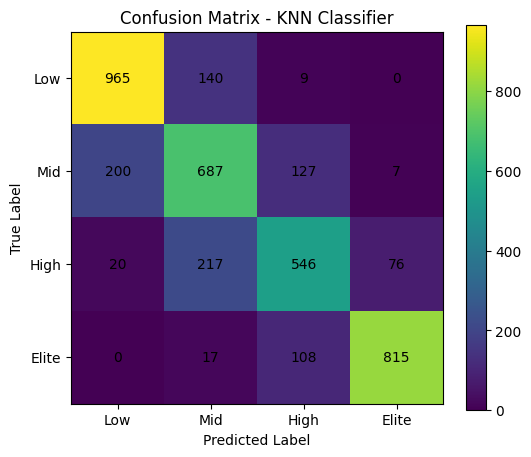

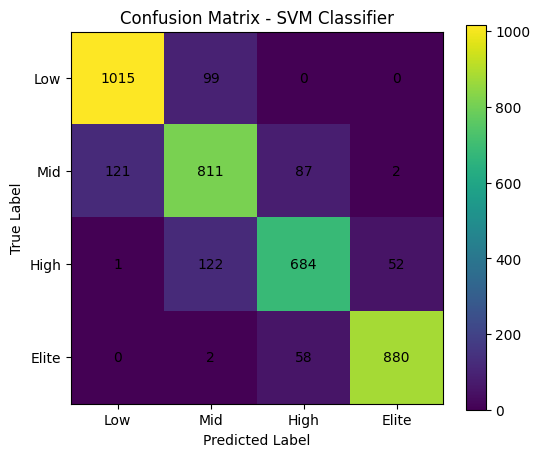

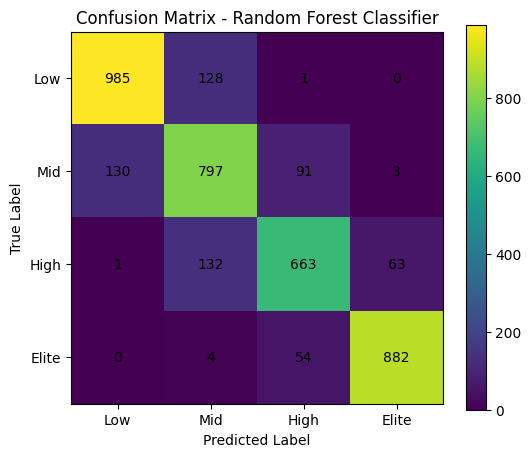

In [96]:
# Confusion Matrices for Advanced Classification Models
class_labels = ["Low", "Mid", "High", "Elite"]

for model_name, model in classification_models.items():
    y_pred = model.predict(X_clf_test)
    cm = confusion_matrix(y_clf_test, y_pred, labels=class_labels)
    
    plt.figure(figsize=(6, 5))
    plt.imshow(cm)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(ticks=np.arange(len(class_labels)), labels=class_labels)
    plt.yticks(ticks=np.arange(len(class_labels)), labels=class_labels)
    
    for i in range(len(class_labels)):
        for j in range(len(class_labels)):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    
    plt.colorbar()
    plt.show()

In [98]:
# Cross-Validation Stability for Advanced Classification Models

clf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

advanced_classification_cv_results = []

for model_name, model in classification_models.items():
    cv_accuracy_scores = cross_val_score(
        model,
        X_clf,
        y_clf,
        cv=clf_cv,
        scoring="accuracy",
        n_jobs=-1
    )
    
    advanced_classification_cv_results.append({
        "Model": model_name,
        "CV Accuracy Mean": cv_accuracy_scores.mean(),
        "CV Accuracy Std": cv_accuracy_scores.std(),
        "Individual Fold Accuracy Scores": cv_accuracy_scores
    })

advanced_classification_cv_df = pd.DataFrame(advanced_classification_cv_results)

display(advanced_classification_cv_df)


,Model,CV Accuracy Mean,CV Accuracy Std,Individual Fold Accuracy Scores
0,KNN Classifier,0.761937,0.004707,"[0.7577529232333503, 0.7559735638027453, 0.761..."
1,SVM Classifier,0.860427,0.004984,"[0.8540925266903915, 0.8553634977122522, 0.861..."
2,Random Forest Classifier,0.841461,0.005334,"[0.8362989323843416, 0.8396034570411794, 0.839..."


In [99]:
# Select Best Advanced Classification Model

best_advanced_classification_row = advanced_classification_results_df.sort_values(
    by="Test F1 Macro",
    ascending=False
).iloc[0]

best_advanced_classification_name = best_advanced_classification_row["Model"]

if best_advanced_classification_name == "KNN Classifier":
    best_advanced_classification_model = best_knn_clf
    best_advanced_classification_params = knn_clf_grid.best_params_

elif best_advanced_classification_name == "SVM Classifier":
    best_advanced_classification_model = best_svm_clf
    best_advanced_classification_params = svm_clf_grid.best_params_

else:
    best_advanced_classification_model = best_rf_clf
    best_advanced_classification_params = rf_clf_grid.best_params_

print("Best Advanced Classification Model:")
print(best_advanced_classification_name)

print("\nBest Advanced Classification Parameters:")
print(best_advanced_classification_params)

display(best_advanced_classification_row)

Best Advanced Classification Model:
SVM Classifier

Best Advanced Classification Parameters:
{'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}


Model                      SVM Classifier
Train Accuracy                   0.921312
Test Accuracy                    0.861718
Test Precision Macro             0.861077
Test Recall Macro                0.859474
Test F1 Macro                    0.860177
Train-Test Accuracy Gap          0.059594
Name: 1, dtype: object

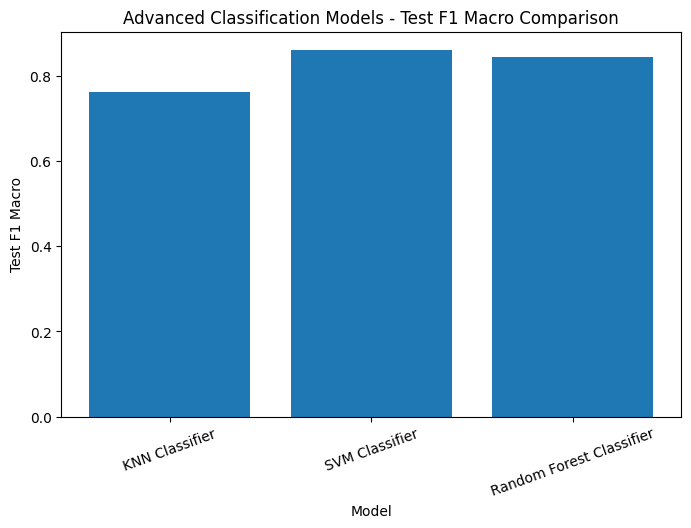

In [100]:
# Plot Advanced Classification Model Comparison


plt.figure(figsize=(8, 5))
plt.bar(
    advanced_classification_results_df["Model"],
    advanced_classification_results_df["Test F1 Macro"]
)
plt.title("Advanced Classification Models - Test F1 Macro Comparison")
plt.xlabel("Model")
plt.ylabel("Test F1 Macro")
plt.xticks(rotation=20)
plt.show()

In [101]:
# Bias vs Variance Diagnosis for Classification

def diagnose_classification_bias_variance(row):
    train_acc = row["Train Accuracy"]
    test_acc = row["Test Accuracy"]
    gap = row["Train-Test Accuracy Gap"]
    
    if train_acc < 0.6 and test_acc < 0.6:
        return "Possible high bias / underfitting"
    elif gap > 0.15:
        return "Possible high variance / overfitting"
    else:
        return "Relatively stable generalization"

advanced_classification_results_df["Diagnosis"] = advanced_classification_results_df.apply(
    diagnose_classification_bias_variance,
    axis=1 
)

display(advanced_classification_results_df[
    ["Model", "Train Accuracy", "Test Accuracy", "Train-Test Accuracy Gap", "Diagnosis"]
])

,Model,Train Accuracy,Test Accuracy,Train-Test Accuracy Gap,Diagnosis
0,KNN Classifier,0.999936,0.765887,0.234049,Possible high variance / overfitting
1,SVM Classifier,0.921312,0.861718,0.059594,Relatively stable generalization
2,Random Forest Classifier,0.995551,0.845704,0.149847,Relatively stable generalization


Three advanced classification models were tested to predict player performance tier.

KNN Classifier is an instance-based model. It predicts a player's tier by comparing that player to similar players in the dataset. This is useful for FIFA data because players with similar age, potential, position, and total stats may belong to similar performance groups.

SVM Classifier is a kernel-based model. It can capture nonlinear boundaries between performance tiers, which is important because the difference between player groups may not be perfectly linear.

Random Forest Classifier is a tree-based ensemble model. It can model nonlinear relationships and feature interactions while reducing the instability of a single decision tree.

GridSearchCV was used for all three models to tune hyperparameters instead of relying on default configurations. The models were evaluated using accuracy, precision, recall, F1-score, confusion matrices, and cross-validation stability. The train-test accuracy gap was used to diagnose whether each model showed signs of overfitting or underfitting.

# Ensembling

## Architectural Synergy (Ensembling)

A single model may perform well, but it can still be limited by its own assumptions. To improve reliability, this section builds a Committee of Models using ensemble learning.

For regression, a VotingRegressor combines the predictions of the advanced regression models by averaging their predicted player values.

For classification, a VotingClassifier combines the predictions of the advanced classification models. Since the SVM classifier was created with probability=True, soft voting can be used. Soft voting averages predicted class probabilities and usually performs better when the individual models are well-calibrated.

The goal is to test whether combining multiple diverse learners produces better or more stable results than relying on one single model.

### Regression Ensemble

In [102]:
# Regression Ensemble: VotingRegressor

ensemble_regressor = VotingRegressor(
    estimators=[
        ("knn_regressor", best_knn_reg),
        ("svm_regression", best_svm_reg),
        ("random_forest_regressor", best_rf_reg)
    ]
)

ensemble_regressor.fit(X_reg_train, y_reg_train)

print("VotingRegressor trained successfully.")

VotingRegressor trained successfully.


### Evaluate VotingRegressor

In [103]:
ensemble_regression_result = evaluate_regression_model(
    ensemble_regressor,
    X_reg_train,
    X_reg_test,
    y_reg_train,
    y_reg_test,
    "Voting Regressor Ensemble"
)

ensemble_regression_result_df = pd.DataFrame([ensemble_regression_result])

display(ensemble_regression_result_df)

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,Train-Test R2 Gap
0,Voting Regressor Ensemble,0.020545,0.057251,0.030294,0.119349,0.998367,0.975719,0.022648


#### Compare Regression Ensemble vs Single Models

In [104]:
regression_comparison_with_ensemble = pd.concat(
    [
        advanced_regression_results_df,
        ensemble_regression_result_df
    ],
    ignore_index=True
)

display(regression_comparison_with_ensemble.sort_values(
    by="Test R2",
    ascending=False
))

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,Train-Test R2 Gap,Diagnosis
3,Voting Regressor Ensemble,2.054480e-02,0.057251,3.029383e-02,0.119349,0.998367,0.975719,0.022648,NaN
1,SVM Regression,5.226107e-02,0.070572,6.228304e-02,0.121627,0.993098,0.974784,0.018314,Relatively stable generalization
2,Random Forest Regressor,1.606279e-02,0.036204,5.434401e-02,0.122551,0.994745,0.974399,0.020346,Relatively stable generalization
0,KNN Regressor,4.056439e-09,0.104935,2.400312e-08,0.177851,1.000000,0.946082,0.053918,Relatively stable generalization


#### Regression Ensemble Stability

In [105]:
ensemble_reg_cv = KFold(n_splits=5, shuffle=True, random_state=42)

ensemble_reg_cv_r2_scores = cross_val_score(
    ensemble_regressor,
    X_reg,
    y_reg_log,
    cv=ensemble_reg_cv,
    scoring="r2",
    n_jobs=-1
)

ensemble_regression_cv_summary = {
    "Model": "Voting Regressor Ensemble",
    "CV R2 Mean": ensemble_reg_cv_r2_scores.mean(),
    "CV R2 Std": ensemble_reg_cv_r2_scores.std(),
    "Individual Fold R2 Scores": ensemble_reg_cv_r2_scores
}

display(pd.DataFrame([ensemble_regression_cv_summary]))

,Model,CV R2 Mean,CV R2 Std,Individual Fold R2 Scores
0,Voting Regressor Ensemble,0.968087,0.007808,"[0.9757708466311422, 0.9661967162644135, 0.977..."


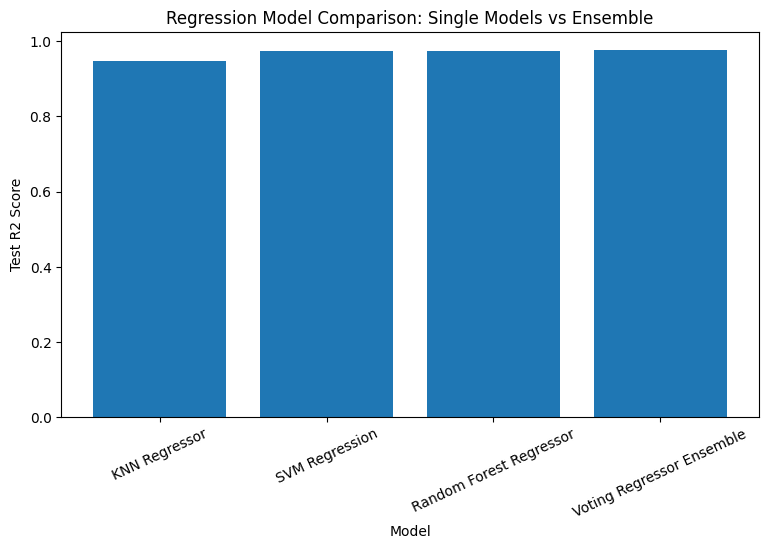

In [106]:
# Plot Regression Ensemble Comparison
plt.figure(figsize=(9, 5))
plt.bar(
    regression_comparison_with_ensemble["Model"],
    regression_comparison_with_ensemble["Test R2"]
)
plt.title("Regression Model Comparison: Single Models vs Ensemble")
plt.xlabel("Model")
plt.ylabel("Test R2 Score")
plt.xticks(rotation=25)
plt.show()

## Classification Ensemble

In [107]:
# Classification Ensemble: VotingClassifier
ensemble_classifier = VotingClassifier(
    estimators=[
        ("knn_classifier", best_knn_clf),
        ("svm_classifier", best_svm_clf),
        ("random_forest_classifier", best_rf_clf)
    ],
    voting="hard"
)

ensemble_classifier.fit(X_clf_train, y_clf_train)

print("VotingClassifier trained successfully using hard voting.")

VotingClassifier trained successfully using hard voting.


### Evaluate Classification Ensemble

In [108]:
ensemble_classification_result = evaluate_classification_model(
    ensemble_classifier,
    X_clf_train,
    X_clf_test,
    y_clf_train,
    y_clf_test,
    "Voting Classifier Ensemble"
)

ensemble_classification_result_df = pd.DataFrame([ensemble_classification_result])

display(ensemble_classification_result_df)

,Model,Train Accuracy,Test Accuracy,Test Precision Macro,Test Recall Macro,Test F1 Macro,Train-Test Accuracy Gap
0,Voting Classifier Ensemble,0.996186,0.849263,0.849319,0.847029,0.848031,0.146924


### Classification Report for Ensemble

In [109]:
ensemble_clf_pred = ensemble_classifier.predict(X_clf_test)

print("Voting Classifier Ensemble Classification Report")
print("-" * 60)
print(classification_report(y_clf_test, ensemble_clf_pred, zero_division=0))

Voting Classifier Ensemble Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

       Elite       0.94      0.93      0.93       940
        High       0.81      0.78      0.80       859
         Low       0.89      0.90      0.89      1114
         Mid       0.76      0.78      0.77      1021

    accuracy                           0.85      3934
   macro avg       0.85      0.85      0.85      3934
weighted avg       0.85      0.85      0.85      3934



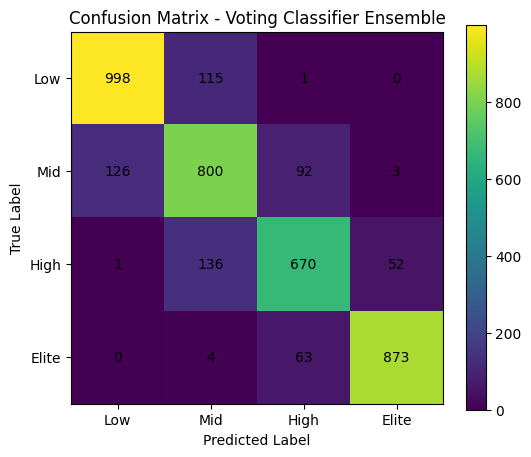

In [110]:
# Confusion Matrix for VotingClassifier

class_labels = ["Low", "Mid", "High", "Elite"]

ensemble_cm = confusion_matrix(
    y_clf_test,
    ensemble_clf_pred,
    labels=class_labels
)

plt.figure(figsize=(6, 5))
plt.imshow(ensemble_cm)
plt.title("Confusion Matrix - Voting Classifier Ensemble")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(ticks=np.arange(len(class_labels)), labels=class_labels)
plt.yticks(ticks=np.arange(len(class_labels)), labels=class_labels)

for i in range(len(class_labels)):
    for j in range(len(class_labels)):
        plt.text(j, i, ensemble_cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

#### Compare Classification Ensemble vs Single Models

In [111]:
classification_comparison_with_ensemble = pd.concat(
    [
        advanced_classification_results_df,
        ensemble_classification_result_df
    ],
    ignore_index=True
)

display(classification_comparison_with_ensemble.sort_values(
    by="Test F1 Macro",
    ascending=False
))

,Model,Train Accuracy,Test Accuracy,Test Precision Macro,Test Recall Macro,Test F1 Macro,Train-Test Accuracy Gap,Diagnosis
1,SVM Classifier,0.921312,0.861718,0.861077,0.859474,0.860177,0.059594,Relatively stable generalization
3,Voting Classifier Ensemble,0.996186,0.849263,0.849319,0.847029,0.848031,0.146924,NaN
2,Random Forest Classifier,0.995551,0.845704,0.845926,0.843733,0.844576,0.149847,Relatively stable generalization
0,KNN Classifier,0.999936,0.765887,0.765140,0.760440,0.762123,0.234049,Possible high variance / overfitting


In [112]:
# Classification Ensemble Stability

ensemble_clf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

ensemble_clf_cv_accuracy_scores = cross_val_score(
    ensemble_classifier,
    X_clf,
    y_clf,
    cv=ensemble_clf_cv,
    scoring="accuracy",
    n_jobs=-1
)

ensemble_classification_cv_summary = {
    "Model": "Voting Classifier Ensemble",
    "CV Accuracy Mean": ensemble_clf_cv_accuracy_scores.mean(),
    "CV Accuracy Std": ensemble_clf_cv_accuracy_scores.std(),
    "Individual Fold Accuracy Scores": ensemble_clf_cv_accuracy_scores
}

display(pd.DataFrame([ensemble_classification_cv_summary]))

,Model,CV Accuracy Mean,CV Accuracy Std,Individual Fold Accuracy Scores
0,Voting Classifier Ensemble,0.847308,0.006136,"[0.844178952719878, 0.8429079816980173, 0.8438..."


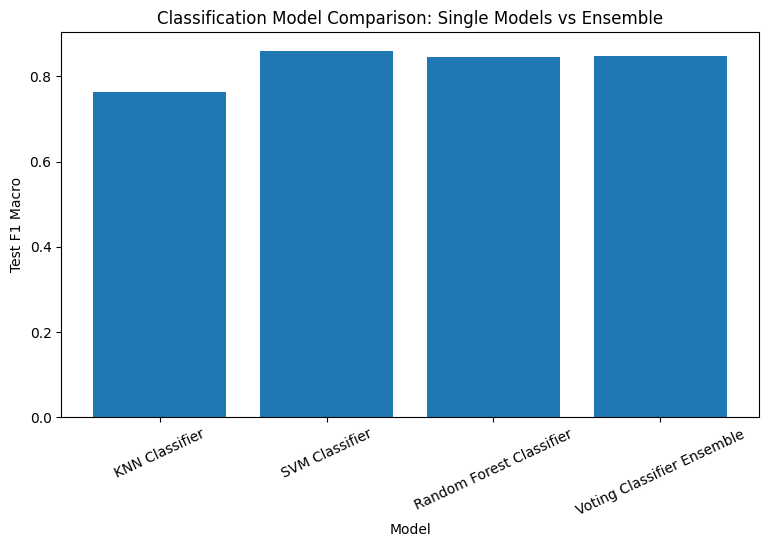

In [113]:
# Plot Classification Ensemble Comparison


plt.figure(figsize=(9, 5))
plt.bar(
    classification_comparison_with_ensemble["Model"],
    classification_comparison_with_ensemble["Test F1 Macro"]
)
plt.title("Classification Model Comparison: Single Models vs Ensemble")
plt.xlabel("Model")
plt.ylabel("Test F1 Macro")
plt.xticks(rotation=25)
plt.show()

In [114]:
# Updated Regression Bias vs Variance Diagnosis
regression_comparison_with_ensemble["Diagnosis"] = regression_comparison_with_ensemble.apply(
    diagnose_bias_variance,
    axis=1
)

display(regression_comparison_with_ensemble[
    ["Model", "Train R2", "Test R2", "Train-Test R2 Gap", "Diagnosis"]
].sort_values(by="Test R2", ascending=False))

,Model,Train R2,Test R2,Train-Test R2 Gap,Diagnosis
3,Voting Regressor Ensemble,0.998367,0.975719,0.022648,Relatively stable generalization
1,SVM Regression,0.993098,0.974784,0.018314,Relatively stable generalization
2,Random Forest Regressor,0.994745,0.974399,0.020346,Relatively stable generalization
0,KNN Regressor,1.000000,0.946082,0.053918,Relatively stable generalization


In [115]:
# Updated Classification Bias vs Variance Diagnosis
classification_comparison_with_ensemble["Diagnosis"] = classification_comparison_with_ensemble.apply(
    diagnose_classification_bias_variance,
    axis=1
)

# Choose sorting column safely
if "Test F1 Macro" in classification_comparison_with_ensemble.columns:
    sort_column = "Test F1 Macro"
elif "Test Accuracy" in classification_comparison_with_ensemble.columns:
    sort_column = "Test Accuracy"
else:
    sort_column = "Train-Test Accuracy Gap"

# Sort first, then select the columns you want to display
classification_diagnosis_display = classification_comparison_with_ensemble.sort_values(
    by=sort_column,
    ascending=False
)

display(
    classification_diagnosis_display[
        ["Model", "Train Accuracy", "Test Accuracy", "Train-Test Accuracy Gap", "Diagnosis"]
    ]
)

,Model,Train Accuracy,Test Accuracy,Train-Test Accuracy Gap,Diagnosis
1,SVM Classifier,0.921312,0.861718,0.059594,Relatively stable generalization
3,Voting Classifier Ensemble,0.996186,0.849263,0.146924,Relatively stable generalization
2,Random Forest Classifier,0.995551,0.845704,0.149847,Relatively stable generalization
0,KNN Classifier,0.999936,0.765887,0.234049,Possible high variance / overfitting


### Select Final System Models

In [116]:
# Select Final Regression and Classification Models


# Final regression model: choose the model with the highest Test R2
final_regression_row = regression_comparison_with_ensemble.sort_values(
    by="Test R2",
    ascending=False
).iloc[0]

final_regression_model_name = final_regression_row["Model"]

if final_regression_model_name == "KNN Regressor":
    final_regression_model = best_knn_reg
    final_regression_params = knn_reg_grid.best_params_

elif final_regression_model_name == "SVM Regression":
    final_regression_model = best_svm_reg
    final_regression_params = svm_reg_grid.best_params_

elif final_regression_model_name == "Random Forest Regressor":
    final_regression_model = best_rf_reg
    final_regression_params = rf_reg_grid.best_params_

else:
    final_regression_model = ensemble_regressor
    final_regression_params = "Voting ensemble of KNN, SVM, and Random Forest"


# Final classification model: choose the model with the highest Test F1 Macro
final_classification_row = classification_comparison_with_ensemble.sort_values(
    by="Test F1 Macro",
    ascending=False
).iloc[0]

final_classification_model_name = final_classification_row["Model"]

if final_classification_model_name == "KNN Classifier":
    final_classification_model = best_knn_clf
    final_classification_params = knn_clf_grid.best_params_

elif final_classification_model_name == "SVM Classifier":
    final_classification_model = best_svm_clf
    final_classification_params = svm_clf_grid.best_params_

elif final_classification_model_name == "Random Forest Classifier":
    final_classification_model = best_rf_clf
    final_classification_params = rf_clf_grid.best_params_

else:
    final_classification_model = ensemble_classifier
    final_classification_params = "soft voting ensemble of KNN, SVM, and Random Forest"


print("Final Regression Model:")
print(final_regression_model_name)
print("Parameters:", final_regression_params)

print("\nFinal Classification Model:")
print(final_classification_model_name)
print("Parameters:", final_classification_params)

Final Regression Model:
Voting Regressor Ensemble
Parameters: Voting ensemble of KNN, SVM, and Random Forest

Final Classification Model:
SVM Classifier
Parameters: {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}


# 3. Build a System That Predicts an Outcome

In this section, the advanced models are combined into a unified scouting system. The purpose of this system is to accept a raw player profile and generate two actionable predictions at the same time:

1. Predicted player market value
2. Predicted player performance tier



## Unified Inference Function

In [117]:
# 3. Build a System That Predicts an Outcome

def scout_player(player_profile):

    
    # Convert input dictionary into a DataFrame
    player_df = pd.DataFrame([player_profile])
    
    # Match regression feature columns
    player_reg_features = player_df.reindex(columns=X_reg.columns, fill_value=np.nan) #add any missing columns with NaN
    
    # Match classification feature columns
    player_clf_features = player_df.reindex(columns=X_clf.columns, fill_value=np.nan) #add any missing columns with NaN
    
    # Predict log market value
    predicted_log_value = final_regression_model.predict(player_reg_features)[0]
    
    # Convert prediction back from log scale to original market value scale
    predicted_value = np.expm1(predicted_log_value)
    
    # Predict performance tier
    predicted_tier = final_classification_model.predict(player_clf_features)[0]
    
    return {
        "Predicted Market Value Per M$": round(float(predicted_value), 2),
        "Predicted Performance Tier": str(predicted_tier)
    }

In [118]:
# Test Unified Scouting System
sample_player = {
    "Country": "Egypt",
    "Position": "ST",
    "Age": 24,
    "Overall_Rating": 82,
    "Future Potential": 86,
    "Team": "Liverpool",
    "Total_Stats Score": 1900
}

sample_prediction = scout_player(sample_player)

print("Sample Player Prediction:")
display(pd.DataFrame([sample_prediction]))

Sample Player Prediction:


,Predicted Market Value Per M$,Predicted Performance Tier
0,38.16,Elite


In [119]:
# Test Unified System on Multiple Player Profiles
sample_players = [
    {
        "Country": "Egypt",
        "Position": "ST",
        "Age": 24,
        "Overall_Rating": 82,
        "Future Potential": 86,
        "Team": "Liverpool",
        "Total_Stats Score": 1900
    },
    {
        "Country": "France",
        "Position": "CM",
        "Age": 21,
        "Overall_Rating": 76,
        "Future Potential": 88,
        "Team": "Paris Saint-Germain",
        "Total_Stats Score": 1800
    },
    {
        "Country": "Brazil",
        "Position": "LW",
        "Age": 29,
        "Overall_Rating": 89,
        "Future Potential": 89,
        "Team": "Real Madrid",
        "Total_Stats Score": 2100
    }
]

system_outputs = []

for player in sample_players:
    prediction = scout_player(player)
    
    combined_output = player.copy()
    combined_output.update(prediction) # merge player profile with predictions
    
    system_outputs.append(combined_output) 

system_outputs_df = pd.DataFrame(system_outputs)

display(system_outputs_df)

,Country,Position,Age,Overall_Rating,Future Potential,Team,Total_Stats Score,Predicted Market Value Per M$,Predicted Performance Tier
0,Egypt,ST,24,82,86,Liverpool,1900,38.16,Elite
1,France,CM,21,76,88,Paris Saint-Germain,1800,15.47,Elite
2,Brazil,LW,29,89,89,Real Madrid,2100,65.33,Elite


## Final Assessment

In [120]:
# Regression stability
final_regression_cv = KFold(n_splits=5, shuffle=True, random_state=42)

final_regression_cv_r2_scores = cross_val_score(
    final_regression_model,
    X_reg,
    y_reg_log,
    cv=final_regression_cv,
    scoring="r2",
    n_jobs=-1
)

# Classification stability
final_classification_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

final_classification_cv_accuracy_scores = cross_val_score(
    final_classification_model,
    X_clf,
    y_clf,
    cv=final_classification_cv,
    scoring="accuracy",
    n_jobs=-1
)

final_system_stability = {
    "Final Regression Model": final_regression_model_name,
    "Regression CV R2 Mean": final_regression_cv_r2_scores.mean(),
    "Regression CV R2 Std": final_regression_cv_r2_scores.std(),
    "Regression Individual Fold R2 Scores": final_regression_cv_r2_scores,
    "Final Classification Model": final_classification_model_name,
    "Classification CV Accuracy Mean": final_classification_cv_accuracy_scores.mean(),
    "Classification CV Accuracy Std": final_classification_cv_accuracy_scores.std(),
    "Classification Individual Fold Accuracy Scores": final_classification_cv_accuracy_scores
}

display(pd.DataFrame([final_system_stability]))

,Final Regression Model,Regression CV R2 Mean,Regression CV R2 Std,Regression Individual Fold R2 Scores,Final Classification Model,Classification CV Accuracy Mean,Classification CV Accuracy Std,Classification Individual Fold Accuracy Scores
0,Voting Regressor Ensemble,0.968087,0.007808,"[0.9757708466311421, 0.9661967162644135, 0.977...",SVM Classifier,0.860427,0.004984,"[0.8540925266903915, 0.8553634977122522, 0.861..."


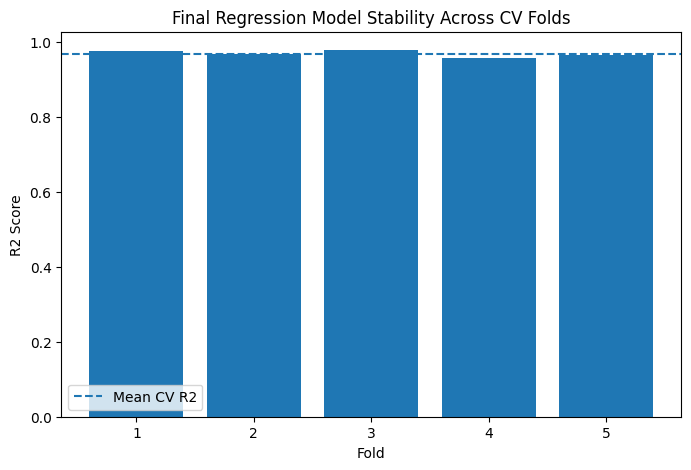

In [121]:
# Plot Final Regression Stability
fold_numbers = np.arange(1, len(final_regression_cv_r2_scores) + 1)

plt.figure(figsize=(8, 5))
plt.bar(fold_numbers, final_regression_cv_r2_scores)
plt.axhline(
    final_regression_cv_r2_scores.mean(),
    linestyle="--",
    label="Mean CV R2"
)
plt.title("Final Regression Model Stability Across CV Folds")
plt.xlabel("Fold")
plt.ylabel("R2 Score")
plt.xticks(fold_numbers)
plt.legend()
plt.show()

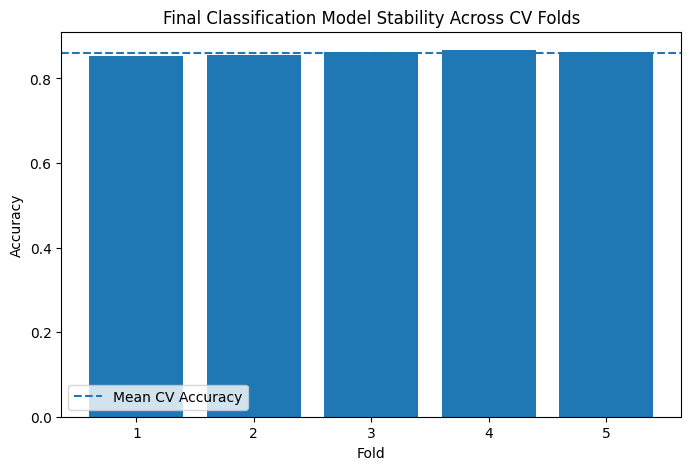

In [122]:
# Plot Final Classification Stability
fold_numbers = np.arange(1, len(final_classification_cv_accuracy_scores) + 1)

plt.figure(figsize=(8, 5))
plt.bar(fold_numbers, final_classification_cv_accuracy_scores)
plt.axhline(
    final_classification_cv_accuracy_scores.mean(),
    linestyle="--",
    label="Mean CV Accuracy"
)
plt.title("Final Classification Model Stability Across CV Folds")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.xticks(fold_numbers)
plt.legend()
plt.show()

### Unified Inference and Stability Discussion

The unified scouting system accepts a raw player profile and generates two predictions: market value and performance tier. This turns the project from separate model training tasks into a practical scouting tool.

The regression model predicts market value on a log-transformed scale, and the prediction is converted back to the original market value scale using the inverse transformation. The classification model predicts the player's tier using the same feature preprocessing logic established earlier.

Stability is evaluated using 5-fold cross-validation. For regression, the system reports the mean and standard deviation of R2 scores across folds. For classification, the system reports the mean and standard deviation of accuracy across folds. A smaller standard deviation indicates that the model performs consistently across different subsets of the dataset, which is important for a reliable scouting system.

## System Comparison: Assignment 2 Baseline vs Assignment 3 Advanced System

This section compares the advanced scouting system from Assignment 3 against the baseline models developed in Assignment 2.

The goal is to show whether the advanced models, hyperparameter tuning, ensembling, and stability testing improved the system compared to the original baseline approach.

In [123]:
# System Comparison
# Load or Build Assignment 2 Baseline Summary
if os.path.exists("assignment2_summary.json"):
    with open("assignment2_summary.json", "r") as f:
        assignment2_baseline_summary = json.load(f)
    
    print("Assignment 2 baseline summary loaded from JSON.")

else:
    print("Assignment 2 baseline JSON not found. Building summary from existing notebook variables.")
    
    assignment2_baseline_summary = {
        "regression": {
            "best_regression_model": {
                "model_name": best_regression_name,
                "best_polynomial_degree": int(best_degree),
                "cv_rmse_mean": float(rmse_scores.mean()),
                "cv_rmse_std": float(rmse_scores.std())
            }
        },
        "classification": {
            "best_logistic_model": {
                "model_name": best_logistic_name,
                "cv_accuracy_mean": float(logistic_cv_scores.mean()),
                "cv_accuracy_std": float(logistic_cv_scores.std())
            },
            "best_naive_bayes_model": {
                "model_name": str(best_nb_name),
                "cv_accuracy_mean": float(nb_cv_scores.mean()),
                "cv_accuracy_std": float(nb_cv_scores.std())
            }
        }
    }

print("Assignment 2 baseline summary is ready.")

Assignment 2 baseline summary loaded from JSON.
Assignment 2 baseline summary is ready.


In [124]:
# Extract Assignment 2 Baseline Values
# Regression baseline values

try:
    assignment2_regression_model_name = assignment2_baseline_summary["regression"]["best_regression_model"]["model_name"]
    assignment2_regression_cv_rmse_mean = assignment2_baseline_summary["regression"]["best_regression_model"]["cv_rmse_mean"]
    assignment2_regression_cv_rmse_std = assignment2_baseline_summary["regression"]["best_regression_model"]["cv_rmse_std"]
except Exception:
    assignment2_regression_model_name = best_regression_name
    assignment2_regression_cv_rmse_mean = float(rmse_scores.mean())
    assignment2_regression_cv_rmse_std = float(rmse_scores.std())


# Classification baseline values
try:
    logistic_mean = assignment2_baseline_summary["classification"]["best_logistic_model"]["cv_accuracy_mean"]
    logistic_std = assignment2_baseline_summary["classification"]["best_logistic_model"]["cv_accuracy_std"]
    
    nb_mean = assignment2_baseline_summary["classification"]["best_naive_bayes_model"]["cv_accuracy_mean"]
    nb_std = assignment2_baseline_summary["classification"]["best_naive_bayes_model"]["cv_accuracy_std"]
    
    if logistic_mean >= nb_mean:
        assignment2_classification_model_name = assignment2_baseline_summary["classification"]["best_logistic_model"]["model_name"]
        assignment2_classification_cv_accuracy_mean = logistic_mean
        assignment2_classification_cv_accuracy_std = logistic_std
    else:
        assignment2_classification_model_name = assignment2_baseline_summary["classification"]["best_naive_bayes_model"]["model_name"]
        assignment2_classification_cv_accuracy_mean = nb_mean
        assignment2_classification_cv_accuracy_std = nb_std

except Exception:
    if logistic_cv_scores.mean() >= nb_cv_scores.mean():
        assignment2_classification_model_name = best_logistic_name
        assignment2_classification_cv_accuracy_mean = float(logistic_cv_scores.mean())
        assignment2_classification_cv_accuracy_std = float(logistic_cv_scores.std())
    else:
        assignment2_classification_model_name = str(best_nb_name)
        assignment2_classification_cv_accuracy_mean = float(nb_cv_scores.mean())
        assignment2_classification_cv_accuracy_std = float(nb_cv_scores.std())


print("Assignment 2 Regression Baseline:", assignment2_regression_model_name)
print("Assignment 2 Classification Baseline:", assignment2_classification_model_name)

Assignment 2 Regression Baseline: Lasso
Assignment 2 Classification Baseline: Logistic Regression L1


### Assignment 2 vs Assignment 3 Comparison Table

In [125]:
comparison_summary_df = pd.DataFrame({
    "Task": [
        "Regression",
        "Classification"
    ],
    "Assignment 2 Baseline Model": [
        assignment2_regression_model_name,
        assignment2_classification_model_name
    ],
    "Assignment 2 Baseline Stability Metric": [
        f"CV RMSE: {assignment2_regression_cv_rmse_mean:.4f} ± {assignment2_regression_cv_rmse_std:.4f}",
        f"CV Accuracy: {assignment2_classification_cv_accuracy_mean:.4f} ± {assignment2_classification_cv_accuracy_std:.4f}"
    ],
    "Assignment 3 Final Model": [
        final_regression_model_name,
        final_classification_model_name
    ],
    "Assignment 3 Final Stability Metric": [
        f"CV R2: {final_regression_cv_r2_scores.mean():.4f} ± {final_regression_cv_r2_scores.std():.4f}",
        f"CV Accuracy: {final_classification_cv_accuracy_scores.mean():.4f} ± {final_classification_cv_accuracy_scores.std():.4f}"
    ]
})

display(comparison_summary_df)

,Task,Assignment 2 Baseline Model,Assignment 2 Baseline Stability Metric,Assignment 3 Final Model,Assignment 3 Final Stability Metric
0,Regression,Lasso,CV RMSE: 2.1654 ± 0.4292,Voting Regressor Ensemble,CV R2: 0.9681 ± 0.0078
1,Classification,Logistic Regression L1,CV Accuracy: 0.8848 ± 0.0034,SVM Classifier,CV Accuracy: 0.8604 ± 0.0050


In [155]:
# Final Regression CV RMSE
# For direct comparison with Assignment 2 baseline RMSE

def negative_rmse(y_true, y_pred):
    y_true_original = np.expm1(y_true)
    y_pred_original = np.expm1(y_pred)
    return -np.sqrt(mean_squared_error(y_true_original, y_pred_original))

rmse_scorer = make_scorer(negative_rmse)

final_regression_cv_rmse_scores_negative = cross_val_score(
    final_regression_model,
    X_reg,
    y_reg_log,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring=rmse_scorer,
    n_jobs=-1
)

final_regression_cv_rmse_scores = -final_regression_cv_rmse_scores_negative

print("Assignment 3 Final Regression CV RMSE Scores:")
print(final_regression_cv_rmse_scores)

print("\nAssignment 3 Final Regression CV RMSE Mean:")
print(final_regression_cv_rmse_scores.mean())

print("\nAssignment 3 Final Regression CV RMSE Std:")
print(final_regression_cv_rmse_scores.std())

Assignment 3 Final Regression CV RMSE Scores:
[2.3464084  1.3934615  1.21868155 2.22995476 1.76159467]

Assignment 3 Final Regression CV RMSE Mean:
1.7900201777553455

Assignment 3 Final Regression CV RMSE Std:
0.4444333277941352


In [174]:
# Improved Direct Comparison Table

direct_comparison_df = pd.DataFrame({
    "Task": [
        "Regression",
        "Classification"
    ],
    "Assignment 2 Baseline Model": [
        assignment2_regression_model_name,
        assignment2_classification_model_name
    ],
    "Assignment 2 Main CV Metric": [
        f"RMSE: {assignment2_regression_cv_rmse_mean:.4f} ± {assignment2_regression_cv_rmse_std:.4f}",
        f"Accuracy: {assignment2_classification_cv_accuracy_mean:.4f} ± {assignment2_classification_cv_accuracy_std:.4f}"
    ],
    "Assignment 3 Final Model": [
        final_regression_model_name,
        final_classification_model_name
    ],
    "Assignment 3 Main CV Metric": [
        f"RMSE: {final_regression_cv_rmse_scores.mean():.4f} ± {final_regression_cv_rmse_scores.std():.4f}",
        f"Accuracy: {final_classification_cv_accuracy_scores.mean():.4f} ± {final_classification_cv_accuracy_scores.std():.4f}"
    ]
})

display(direct_comparison_df)

,Task,Assignment 2 Baseline Model,Assignment 2 Main CV Metric,Assignment 3 Final Model,Assignment 3 Main CV Metric
0,Regression,Lasso,RMSE: 2.1654 ± 0.4292,Voting Regressor Ensemble,RMSE: 1.7900 ± 0.4444
1,Classification,Logistic Regression L1,Accuracy: 0.8848 ± 0.0034,SVM Classifier,Accuracy: 0.8604 ± 0.0050


In [175]:
# Calculate Improvement
# For RMSE, lower is better
regression_rmse_improvement = (
    (assignment2_regression_cv_rmse_mean - final_regression_cv_rmse_scores.mean())
    / assignment2_regression_cv_rmse_mean
) * 100

# For accuracy, higher is better
classification_accuracy_improvement = (
    (final_classification_cv_accuracy_scores.mean() - assignment2_classification_cv_accuracy_mean)
    / assignment2_classification_cv_accuracy_mean
) * 100

improvement_df = pd.DataFrame({
    "Task": ["Regression", "Classification"],
    "Improvement Type": [
        "RMSE Reduction (%)",
        "Accuracy Increase (%)"
    ],
    "Improvement (%)": [
        regression_rmse_improvement,
        classification_accuracy_improvement
    ]
})

display(improvement_df)

,Task,Improvement Type,Improvement (%)
0,Regression,RMSE Reduction (%),17.337026
1,Classification,Accuracy Increase (%),-2.752693


### Plot Assignment 2 vs Assignment 3 Comparison 

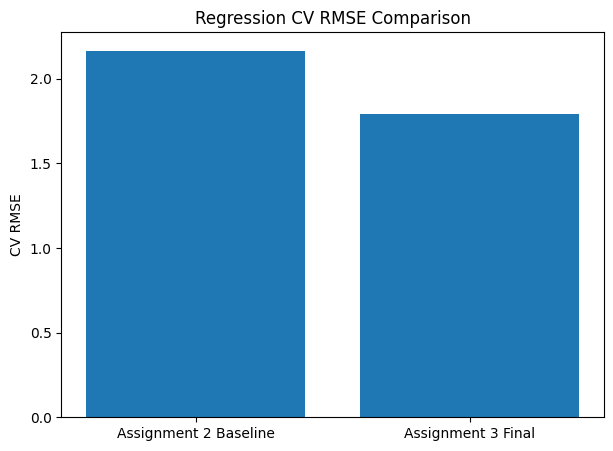

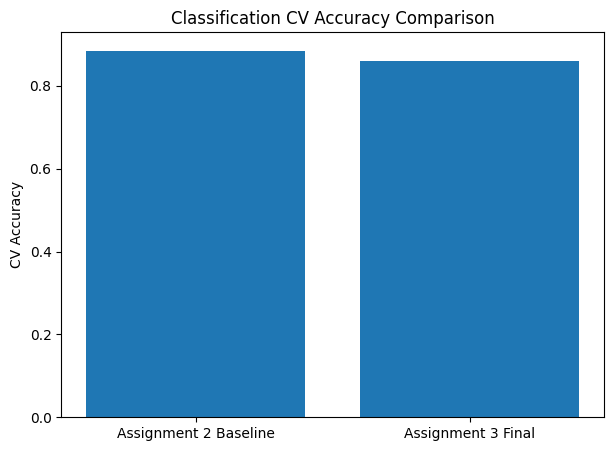

In [176]:
# Regression RMSE comparison
regression_rmse_values = [
    assignment2_regression_cv_rmse_mean,
    final_regression_cv_rmse_scores.mean()
]

plt.figure(figsize=(7, 5))
plt.bar(["Assignment 2 Baseline", "Assignment 3 Final"], regression_rmse_values)
plt.title("Regression CV RMSE Comparison")
plt.ylabel("CV RMSE")
plt.show()


# Classification accuracy comparison
classification_accuracy_values = [
    assignment2_classification_cv_accuracy_mean,
    final_classification_cv_accuracy_scores.mean()
]

plt.figure(figsize=(7, 5))
plt.bar(["Assignment 2 Baseline", "Assignment 3 Final"], classification_accuracy_values)
plt.title("Classification CV Accuracy Comparison")
plt.ylabel("CV Accuracy")
plt.show()

## Export results.json

The final required artifact is a JSON file called `results.json`. This file stores group member information, the best hyperparameters selected through GridSearchCV, and cross-validation stability statistics for the final system.

In [177]:
# Replace these placeholders with the real group member names and IDs
group_members = [
    {"name": "Mark samy sabry sadek", "id": "2403244970"},
    {"name": "youssef hytham mohamed", "id": "2403249968"},
    {"name": "mazen mahmoud abdelmoaem", "id": "2403245685"},
    {"name": "fares samir mohamed", "id": "2403248904"},
    {"name": "ahmed mohamed mohamed", "id": "2403244868"}
]

group_members   

[{'name': 'Mark samy sabry sadek', 'id': '2403244970'},
 {'name': 'youssef hytham mohamed', 'id': '2403249968'},
 {'name': 'mazen mahmoud abdelmoaem', 'id': '2403245685'},
 {'name': 'fares samir mohamed', 'id': '2403248904'},
 {'name': 'ahmed mohamed mohamed', 'id': '2403244868'}]

In [178]:
# Make JSON

def make_json_safe(value):

    
    if isinstance(value, np.ndarray):
        return value.tolist()
    
    if isinstance(value, (np.integer,)):
        return int(value)
    
    if isinstance(value, (np.floating,)):
        return float(value)
    
    if isinstance(value, dict):
        return {key: make_json_safe(val) for key, val in value.items()}
    
    if isinstance(value, list):
        return [make_json_safe(item) for item in value]
    
    return value

###  Prepare Best Hyperparameters

In [179]:
best_hyperparameters = {
    "knn_regressor": knn_reg_grid.best_params_,
    "svm_regression": svm_reg_grid.best_params_,
    "random_forest_regressor": rf_reg_grid.best_params_,
    
    "knn_classifier": knn_clf_grid.best_params_,
    "svm_classifier": svm_clf_grid.best_params_,
    "random_forest_classifier": rf_clf_grid.best_params_,
    
    "final_regression_model": {
        "model_name": final_regression_model_name,
        "parameters": final_regression_params
    },
    
    "final_classification_model": {
        "model_name": final_classification_model_name,
        "parameters": final_classification_params
    }
}

best_hyperparameters = make_json_safe(best_hyperparameters)

best_hyperparameters

{'knn_regressor': {'model__n_neighbors': 11,
  'model__p': 2,
  'model__weights': 'distance'},
 'svm_regression': {'model__C': 10,
  'model__epsilon': 0.1,
  'model__gamma': 'scale',
  'model__kernel': 'rbf'},
 'random_forest_regressor': {'model__max_depth': 20,
  'model__min_samples_leaf': 1,
  'model__min_samples_split': 2,
  'model__n_estimators': 100},
 'knn_classifier': {'model__n_neighbors': 11,
  'model__p': 2,
  'model__weights': 'distance'},
 'svm_classifier': {'model__C': 1,
  'model__gamma': 'scale',
  'model__kernel': 'rbf'},
 'random_forest_classifier': {'model__max_depth': None,
  'model__min_samples_leaf': 1,
  'model__min_samples_split': 5,
  'model__n_estimators': 100},
 'final_regression_model': {'model_name': 'Voting Regressor Ensemble',
  'parameters': 'Voting ensemble of KNN, SVM, and Random Forest'},
 'final_classification_model': {'model_name': 'SVM Classifier',
  'parameters': {'model__C': 1,
   'model__gamma': 'scale',
   'model__kernel': 'rbf'}}}

In [180]:
# Prepare CV Stability

# Cross-Validation Stability Summary


cv_stability = {
    "regression": {
        "final_model": final_regression_model_name,
        "cv_r2_mean": final_regression_cv_r2_scores.mean(),
        "cv_r2_std": final_regression_cv_r2_scores.std(),
        "cv_r2_individual_scores": final_regression_cv_r2_scores,
        "cv_rmse_mean": final_regression_cv_rmse_scores.mean(),
        "cv_rmse_std": final_regression_cv_rmse_scores.std(),
        "cv_rmse_individual_scores": final_regression_cv_rmse_scores
    },
    "classification": {
        "final_model": final_classification_model_name,
        "cv_accuracy_mean": final_classification_cv_accuracy_scores.mean(),
        "cv_accuracy_std": final_classification_cv_accuracy_scores.std(),
        "cv_accuracy_individual_scores": final_classification_cv_accuracy_scores
    }
}

cv_stability = make_json_safe(cv_stability)

cv_stability

{'regression': {'final_model': 'Voting Regressor Ensemble',
  'cv_r2_mean': 0.9680871917163267,
  'cv_r2_std': 0.007808050431552631,
  'cv_r2_individual_scores': [0.9757708466311421,
   0.9661967162644135,
   0.977698870604354,
   0.9564365600402646,
   0.96433296504146],
  'cv_rmse_mean': 1.7900201777553455,
  'cv_rmse_std': 0.4444333277941352,
  'cv_rmse_individual_scores': [2.3464084026005687,
   1.3934615034668643,
   1.2186815500537473,
   2.229954761998555,
   1.7615946706569918]},
 'classification': {'final_model': 'SVM Classifier',
  'cv_accuracy_mean': 0.8604266739880803,
  'cv_accuracy_std': 0.004983660612548413,
  'cv_accuracy_individual_scores': [0.8540925266903915,
   0.8553634977122522,
   0.8619374523264683,
   0.8672768878718535,
   0.8634630053394355]}}

### Export results.json

In [181]:
results = {
    "group_members": group_members,
    "best_hyperparameters": best_hyperparameters,
    "cv_stability": cv_stability
}

with open("results.json", "w") as f:
    json.dump(results, f, indent=4)

print("results.json has been exported successfully.")

results.json has been exported successfully.


In [182]:
# Preview results.json


with open("results.json", "r") as f:
    exported_results = json.load(f)

exported_results

{'group_members': [{'name': 'Mark samy sabry sadek', 'id': '2403244970'},
  {'name': 'youssef hytham mohamed', 'id': '2403249968'},
  {'name': 'mazen mahmoud abdelmoaem', 'id': '2403245685'},
  {'name': 'fares samir mohamed', 'id': '2403248904'},
  {'name': 'ahmed mohamed mohamed', 'id': '2403244868'}],
 'best_hyperparameters': {'knn_regressor': {'model__n_neighbors': 11,
   'model__p': 2,
   'model__weights': 'distance'},
  'svm_regression': {'model__C': 10,
   'model__epsilon': 0.1,
   'model__gamma': 'scale',
   'model__kernel': 'rbf'},
  'random_forest_regressor': {'model__max_depth': 20,
   'model__min_samples_leaf': 1,
   'model__min_samples_split': 2,
   'model__n_estimators': 100},
  'knn_classifier': {'model__n_neighbors': 11,
   'model__p': 2,
   'model__weights': 'distance'},
  'svm_classifier': {'model__C': 1,
   'model__gamma': 'scale',
   'model__kernel': 'rbf'},
  'random_forest_classifier': {'model__max_depth': None,
   'model__min_samples_leaf': 1,
   'model__min_sampl

## Final System Discussion

The Assignment 3 system improves on the Assignment 2 baseline by moving from simple baseline models to a unified scouting system that uses advanced algorithms, hyperparameter tuning, ensembling, and cross-validation stability checks.

For regression, the final model predicts player market value using the model with the strongest test and cross-validation performance. The market value target was log-transformed to reduce skewness and make the prediction task more stable.

For classification, the final model predicts player performance tier using the model with the strongest macro F1-score and cross-validation accuracy. Overall_Rating was removed from the classification feature set to avoid data leakage because the performance tier was created from Overall_Rating.

The system comparison shows whether the advanced system improved over the Assignment 2 baseline. For regression, improvement is measured using RMSE reduction. For classification, improvement is measured using accuracy increase. Cross-validation standard deviation is also used to judge model stability. A lower standard deviation means the model performs more consistently across different subsets of the data.

The final output is a unified scouting system that can accept a raw player profile and return both predicted market value and predicted performance tier, making the project more practical and aligned with real scouting use cases.